# A covariance-aware compressed reanalysis of Pantheon+SH0ES

### Analytic GLS, MCMC and robustness tests for the local inference of $H_0$

## Scientific question

How robust is the inferred value of the Hubble constant to changes in the distance-redshift model, covariance treatment, fixed cosmographic parameters and Hubble-flow selection?

## Abstract

This notebook presents a pedagogical, covariance-aware reanalysis of the public Pantheon+SH0ES distance products. It combines 77 calibrator rows and 277 Hubble-flow rows using the published full covariance matrix and a third-order cosmographic distance relation. The two-parameter model for $H_0$ and the standardized supernova absolute magnitude $M_{\rm SN}$ is solved analytically with generalized least squares and sampled independently with MCMC. The baseline result is

$$
H_0=73.529\pm1.048\ \mathrm{km\,s^{-1}\,Mpc^{-1}}.
$$

Residual diagnostics, an additional-scatter extension and predefined robustness tests are used to determine which assumptions affect the central value and which primarily affect its uncertainty. Because the input magnitudes, Cepheid distances and covariance matrices are already calibrated Pantheon+SH0ES products, this analysis is not an independent measurement of $H_0$ or a reconstruction of the complete distance ladder.


## Notebook roadmap

**Front matter — Data provenance and citations**
Identification of the public data products, pinned Git commit and scientific references.

### I. Data, model and analytic validation

1. **Data import and validation** — Validate the data–covariance alignment, define the analysis sample and count rows and unique `CID` values.
2. **Model and covariance-aware likelihood** — Define the calibrator and Hubble-flow models and the multivariate Gaussian posterior.
3. **Maximum-posterior sanity check** — Locate and verify the numerical posterior maximum.
4. **Analytic generalized least-squares validation** — Validate the likelihood and numerical result with an independent GLS solution.

### II. Bayesian inference and diagnostics

5. **MCMC sampling of the baseline posterior** — Sample the joint posterior of $H_0$ and $M_{\rm SN}$.
6. **MCMC diagnostics** — Assess convergence using traces, acceptance fractions, autocorrelation times and effective sample sizes.
7. **Additional-scatter robustness extension** — Determine whether the data require an additional magnitude scatter $\sigma_{\rm extra}$.
8. **Baseline residuals and goodness of fit** — Examine raw and whitened residuals, $\chi^2$ and the upper-tail probability.

### III. Robustness and scientific interpretation

9. **Robustness tests** — Test the effects of covariance treatment, distance model, fixed cosmography and sample selection.
10. **Conclusions and limitations** — Summarize the main results and define the scientific scope of the reanalysis.


## Data provenance and citations

The data are downloaded at runtime from the public [Pantheon+SH0ES Data Release](https://github.com/PantheonPlusSH0ES/DataRelease). To prevent later changes to the repository from modifying the analysis, all download URLs are pinned to the following Git commit:

```text
c447f0fea703fcd0fff57de5000947b5ca81286b
```

The analysis uses three published data products:

* `Pantheon+SH0ES.dat`, containing the corrected supernova magnitudes, redshifts, Cepheid distance moduli and published selection flags;
* `Pantheon+SH0ES_STAT+SYS.cov`, containing the combined statistical and systematic covariance;
* `Pantheon+SH0ES_STATONLY.cov`, used only for a predefined covariance-sensitivity test.

The covariance matrices are retained in their published ordering and restricted with exactly the same row indices as the selected data. Repeated measurements of the same supernova identifier (`CID`) are preserved, with their dependence represented by the published covariance matrix; they are neither removed nor treated as independent observations.

The data products and scientific methodology should be credited to:

* [Brout et al. (2022), *The Pantheon+ Analysis: Cosmological Constraints*](https://arxiv.org/abs/2202.04077);
* [Riess et al. (2022), *A Comprehensive Measurement of the Local Value of the Hubble Constant with 1 km s$^{-1}$ Mpc$^{-1}$ Uncertainty from the Hubble Space Telescope and the SH0ES Team*](https://arxiv.org/abs/2112.04510);
* the [Pantheon+SH0ES public data release](https://github.com/PantheonPlusSH0ES/DataRelease).

**Data accessed:** 30 August 2026.


## 1. Data import and validation

The goal of this section is to load the public Pantheon+SH0ES data table and its associated covariance matrix.

In the previous notebook, we used only diagonal magnitude uncertainties. In this notebook, we will use the full covariance matrix, which contains correlated statistical and systematic uncertainties.

Before building any likelihood, we must verify that:

1. the data table is loaded correctly;
2. the covariance matrix has the expected dimensions;
3. the row order of the covariance matrix matches the row order of the data table;
4. the selected analysis sample and the selected covariance submatrix have consistent dimensions.

At the end of this section, we want two clean objects:

- `analysis_data`: the selected calibrator and Hubble-flow supernovae;
- `C_analysis`: the covariance submatrix corresponding exactly to the selected rows.

### Reproducibility configuration

The following configuration records the software environment, data-access date and random seeds used by the analysis. The primary input files are downloaded from a fixed Git commit and verified against their expected SHA-256 hashes.

Separate fixed seeds control the initial walker positions and the internal `emcee` proposal sequences.


In [1]:
import hashlib
import platform
from importlib.metadata import version as package_version
from io import BytesIO
from urllib.request import urlopen

import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.integrate import quad
from scipy.optimize import minimize

plt.style.use("default")

c_km_s = 299792.458  # Speed of light in km/s.

DATA_ACCESS_DATE = "2026-08-30"
BASELINE_MCMC_SEED = 42
EXTRA_MCMC_SEED = 43

def download_bytes(url):
    """Download a non-empty file and return its raw bytes."""
    with urlopen(url, timeout=120) as response:
        content = response.read()

    if not content:
        raise RuntimeError(f"No content downloaded from {url}")

    return content

def sha256_digest(content):
    """Return the hexadecimal SHA-256 digest of a byte sequence."""
    return hashlib.sha256(content).hexdigest()

packages = [
    "numpy", "pandas", "scipy", "matplotlib",
    "emcee", "corner", "ipykernel",
]

print(f"Python: {platform.python_version()} ({platform.python_implementation()})")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"Data access date: {DATA_ACCESS_DATE}")
print(f"MCMC seeds: baseline={BASELINE_MCMC_SEED}, extra={EXTRA_MCMC_SEED}")

for package in packages:
    print(f"{package}: {package_version(package)}")

Python: 3.12.10 (CPython)
Platform: Windows 11
Data access date: 2026-08-30
MCMC seeds: baseline=42, extra=43
numpy: 2.5.2
pandas: 3.0.5
scipy: 1.18.0
matplotlib: 3.11.1
emcee: 3.1.6
corner: 2.3.0
ipykernel: 7.3.0


In [2]:
DATA_RELEASE_COMMIT = "c447f0fea703fcd0fff57de5000947b5ca81286b"
EXPECTED_DATA_SHA256 = "1cb0fc379ef066afdc2ffd1857681cc478024570d8a3eba284fb645775198cf8"

BASE_URL = (
    "https://raw.githubusercontent.com/"
    "PantheonPlusSH0ES/DataRelease/"
    f"{DATA_RELEASE_COMMIT}/"
    "Pantheon%2B_Data/4_DISTANCES_AND_COVAR"
)

data_url = f"{BASE_URL}/Pantheon%2BSH0ES.dat"
data_bytes = download_bytes(data_url)
data_sha256 = sha256_digest(data_bytes)

assert data_sha256 == EXPECTED_DATA_SHA256, (
    "Unexpected SHA-256 hash for Pantheon+SH0ES.dat"
)

full_data = pd.read_csv(BytesIO(data_bytes), sep=r"\s+")

print("Data-release commit:", DATA_RELEASE_COMMIT)
print("Data SHA-256:", data_sha256)
print("Data shape:", full_data.shape)
print(full_data.head())

Data-release commit: c447f0fea703fcd0fff57de5000947b5ca81286b
Data SHA-256: 1cb0fc379ef066afdc2ffd1857681cc478024570d8a3eba284fb645775198cf8
Data shape: (1701, 47)
             CID  IDSURVEY      zHD   zHDERR     zCMB  zCMBERR     zHEL  \
0         2011fe        51  0.00122  0.00084  0.00122  0.00002  0.00082   
1         2011fe        56  0.00122  0.00084  0.00122  0.00002  0.00082   
2         2012cg        51  0.00256  0.00084  0.00256  0.00002  0.00144   
3         2012cg        56  0.00256  0.00084  0.00256  0.00002  0.00144   
4  1994DRichmond        50  0.00299  0.00084  0.00299  0.00004  0.00187   

   zHELERR  m_b_corr  m_b_corr_err_DIAG  ...  PKMJDERR  NDOF   FITCHI2  \
0  0.00002   9.74571           1.516210  ...    0.1071    36   26.8859   
1  0.00002   9.80286           1.517230  ...    0.0579   101   88.3064   
2  0.00002  11.47030           0.781906  ...    0.0278   165  233.5000   
3  0.00002  11.49190           0.798612  ...    0.0667    55  100.1220   
4  0.00004  11.

### Required columns

For the covariance-aware distance-ladder model, we need both observational quantities and sample-selection flags.

The central observed quantity is the corrected apparent magnitude $m_{b,\rm corr}$.

For calibrator supernovae, the Cepheid distance modulus is provided through `CEPH_DIST`.

For Hubble-flow supernovae, the redshift `zHD` is used to compute the model distance modulus.

The flags `IS_CALIBRATOR` and `USED_IN_SH0ES_HF` define the two roles of the supernovae in the analysis:

- calibrators constrain $M_{\rm SN}$;
- Hubble-flow supernovae constrain the redshift-distance relation once $M_{\rm SN}$ is calibrated.

In [3]:
required_cols = ["CID", "zHD", "zHEL", "m_b_corr", "CEPH_DIST", "IS_CALIBRATOR", "USED_IN_SH0ES_HF",]

missing_cols = [col for col in required_cols if col not in full_data.columns]

n_available = len(required_cols) - len(missing_cols)

print(f"There are {n_available} / {len(required_cols)} required columns in the data.")

assert not missing_cols, (f"The following required columns are missing: {missing_cols}")

There are 7 / 7 required columns in the data.


In [4]:
n_total = len(full_data)
n_calibration_flag = (full_data["IS_CALIBRATOR"] == 1).sum()
n_ceph_positive = (full_data["CEPH_DIST"] > 0).sum()
n_hubble_flow = (full_data["USED_IN_SH0ES_HF"] == 1).sum()

print("Total number of rows:", n_total)
print("Number of calibrator rows:", n_calibration_flag)
print("Number of rows with positive Cepheid distance modulus:", n_ceph_positive)
print("Number of Hubble-flow rows:", n_hubble_flow)

if n_calibration_flag == n_ceph_positive:
    print("The calibrator flag is consistent with the availability of Cepheid distances")
else:
    print("Warning: the calibrator flag and positive Cepheid distances do not match exactly")

Total number of rows: 1701
Number of calibrator rows: 77
Number of rows with positive Cepheid distance modulus: 77
Number of Hubble-flow rows: 277
The calibrator flag is consistent with the availability of Cepheid distances


### Covariance matrix

The covariance matrix is the key upgrade of this notebook.

In the previous notebook, we assumed independent errors and used only diagonal uncertainties. Here, the data covariance is represented by a full matrix $C_{\rm full}$.

If the data vector has length $N$, then $C_{\rm full}$ must have shape

$$
(N,N).
$$

The diagonal entries represent the variance of each measurement, while the off-diagonal entries represent covariances between different measurements.

This is why the row order matters: row $i$ of the data table must correspond exactly to row and column $i$ of the covariance matrix.


In [5]:
cov_url = f"{BASE_URL}/Pantheon%2BSH0ES_STAT%2BSYS.cov"
EXPECTED_STAT_SYS_SHA256 = "abf806d966485e64afdb359c87bffc0ecc00d05eff0a31ced66f247385df0fdc"

cov_bytes = download_bytes(cov_url)
cov_sha256 = sha256_digest(cov_bytes)

assert cov_sha256 == EXPECTED_STAT_SYS_SHA256, (
    "Unexpected SHA-256 hash for the STAT+SYS covariance")

cov_raw = np.loadtxt(BytesIO(cov_bytes))
print("STAT+SYS covariance SHA-256:", cov_sha256)

N_header = cov_raw[0]
assert np.isfinite(N_header)
assert N_header.is_integer(), "The covariance header is not an integer."

N = int(N_header)
cov_values = cov_raw[1:]

assert N == len(full_data), (
    f"Covariance header N={N}, but the data table has "
    f"{len(full_data)} rows.")

assert cov_values.size == N**2, (
    f"Expected {N**2} covariance values, "
    f"but found {cov_values.size}.")

C_full_raw = cov_values.reshape(N, N)

print("N from covariance header:", N)
print("Number of covariance values:", cov_values.size)
print("Raw covariance shape:", C_full_raw.shape)

STAT+SYS covariance SHA-256: abf806d966485e64afdb359c87bffc0ecc00d05eff0a31ced66f247385df0fdc
N from covariance header: 1701
Number of covariance values: 2893401
Raw covariance shape: (1701, 1701)


### Covariance validation

Before using the covariance matrix in a likelihood, we perform several sanity checks.

A valid covariance matrix for our analysis should be:

1. square;
2. symmetric;
3. finite;
4. positive on the diagonal;
5. consistent in dimension with the data table.

The off-diagonal entries are important: they encode correlated statistical and systematic uncertainties. If we ignored them, we would return to the diagonal-error approximation of the previous notebook.

In [6]:
# 1. Shape
assert C_full_raw.shape == (N, N)

# 2. Finite values
assert np.isfinite(C_full_raw).all()
assert np.all(np.diag(C_full_raw) > 0)

# 3. Symmetry
max_asym = np.max(np.abs(C_full_raw - C_full_raw.T))
symmetry_atol = 1e-7  # mag^2

print(f"Maximum |C - C.T|: {max_asym:.3e} mag^2")
print("Symmetric within the chosen tolerance:", np.allclose(C_full_raw, C_full_raw.T, rtol=0.0, atol=symmetry_atol,),)

assert np.allclose(
    C_full_raw,
    C_full_raw.T,
    rtol=0.0,
    atol=symmetry_atol,
), "The covariance asymmetry is too large to be attributed to file rounding."

if max_asym > 0:
    C_full = 0.5 * (C_full_raw + C_full_raw.T)
    print("The covariance was symmetrized.")
else:
    C_full = C_full_raw.copy()
    print("No symmetrization was necessary.")

assert np.array_equal(C_full, C_full.T)
assert np.count_nonzero(C_full) > N

print("Exactly symmetric after validation:", np.array_equal(C_full, C_full.T))

# 4. Positive diagonal
print("Positive diagonal:", np.all(np.diag(C_full) > 0))

# 5. Non-null off-diagonal
print("Contains non-zero off-diagonal terms:", np.count_nonzero(C_full) > N)

Maximum |C - C.T|: 3.000e-08 mag^2
Symmetric within the chosen tolerance: True
The covariance was symmetrized.
Exactly symmetric after validation: True
Positive diagonal: True
Contains non-zero off-diagonal terms: True


### Sample selection

We use two types of supernovae.

Calibrator supernovae have an independent Cepheid distance modulus. They constrain the standardized absolute magnitude $M_{\rm SN}$.

Hubble-flow supernovae are used to constrain the redshift-distance relation and therefore $H_0$ once $M_{\rm SN}$ is calibrated.

For the main analysis, we use the published Hubble-flow flag `USED_IN_SH0ES_HF`. This avoids introducing an arbitrary redshift cut by hand.

Each row must enter the analysis only once. If a row were both a calibrator and a Hubble-flow object, we would treat it as a calibrator and remove it from the Hubble-flow subset.

In [7]:
calib_mask = full_data["IS_CALIBRATOR"].eq(1).to_numpy()
hf_mask_raw = full_data["USED_IN_SH0ES_HF"].eq(1).to_numpy()

assert calib_mask.shape == (N,)
assert hf_mask_raw.shape == (N,)

overlap_mask = calib_mask & hf_mask_raw

print("Number of overlapping rows:", np.count_nonzero(overlap_mask))
assert not np.any(overlap_mask)

hf_mask = hf_mask_raw & ~calib_mask
analysis_mask = calib_mask | hf_mask

analysis_indexes = np.flatnonzero(analysis_mask)

assert len(analysis_indexes) == np.count_nonzero(analysis_mask)
assert np.all(np.diff(analysis_indexes) > 0)

print("Calibrator rows:", np.count_nonzero(calib_mask))
print("Hubble-flow rows:", np.count_nonzero(hf_mask))
print("Selected rows:", len(analysis_indexes))

Number of overlapping rows: 0
Calibrator rows: 77
Hubble-flow rows: 277
Selected rows: 354


### Analysis dataframe and covariance submatrix

The covariance matrix must follow exactly the same row selection as the data vector.

If the analysis sample contains $N_{\rm analysis}$ rows, then the residual vector will have shape

$$
(N_{\rm analysis},)
$$

and the selected covariance matrix must have shape

$$
(N_{\rm analysis}, N_{\rm analysis}).
$$

The selected covariance matrix is not built from scratch. It is obtained by selecting the same rows and columns from the full covariance matrix as the rows selected in `analysis_data`.

This preserves the published covariance structure between all selected supernovae.

In [8]:
# The original RangeIndex represents the row positions used by the covariance.
assert np.array_equal(full_data.index.to_numpy(), np.arange(N))

analysis_data = full_data.iloc[analysis_indexes].copy()

C_analysis = C_full[np.ix_(analysis_indexes, analysis_indexes)]

n_analysis = len(analysis_data)

assert np.array_equal(
    analysis_data.index.to_numpy(),
    analysis_indexes,
)

assert len(analysis_indexes) == n_analysis
assert C_analysis.shape == (n_analysis, n_analysis)

print("analysis_data shape:", analysis_data.shape)
print("C_analysis shape:", C_analysis.shape)
print("Data/covariance order preserved: True")

analysis_data shape: (354, 47)
C_analysis shape: (354, 354)
Data/covariance order preserved: True


In [9]:
assert full_data["CID"].notna().all()
assert analysis_data["CID"].notna().all()

n_unique_cid_full = full_data["CID"].nunique()
n_unique_cid_analysis = analysis_data["CID"].nunique()
n_repeated_rows_analysis = n_analysis - n_unique_cid_analysis

print(f"Full release: {n_total} rows, {n_unique_cid_full} unique CIDs")
print(f"Analysis sample: {n_analysis} rows, {n_unique_cid_analysis} unique CIDs")
print(f"Additional rows from repeated measurements: {n_repeated_rows_analysis}")

assert n_unique_cid_full <= n_total
assert n_unique_cid_analysis <= n_analysis

Full release: 1701 rows, 1543 unique CIDs
Analysis sample: 354 rows, 281 unique CIDs
Additional rows from repeated measurements: 73


The selected sample contains 354 rows but 281 distinct supernova identifiers (`CID`). The difference corresponds to repeated measurements of the same supernovae.

These rows are deliberately retained: repeated light-curve measurements may contain useful information, and their statistical dependence is represented by the published covariance matrix. Removing duplicate identifiers would therefore discard data, whereas treating all rows as independent would underestimate their correlations.

In [10]:
# 1. Check that every covariance coefficient is a finite number

cov_is_finite = np.isfinite(C_analysis).all()
assert cov_is_finite, "C_analysis contains non-finite values."

# 2. Check that the matrix is symmetric
cov_is_symmetric = np.array_equal(C_analysis, C_analysis.T)
assert cov_is_symmetric, "C_analysis is not exactly symmetric."

# 3. Check positivity of diagonal terms
diagonal_variances = np.diag(C_analysis)
has_positive_diagonal = np.all(diagonal_variances > 0)
assert has_positive_diagonal, "C_analysis contains non-positive variances."

# 4. Verify that the matrix contains non-zero off-diagonal terms
has_off_diagonal_terms = np.count_nonzero(C_analysis) > n_analysis
assert has_off_diagonal_terms, "C_analysis has no non-zero off-diagonal terms."

# 5. Check that the observational quantities contain only finite values
required_columns = ["m_b_corr", "zHD","zHEL", "CEPH_DIST"]
required_values = analysis_data[required_columns].to_numpy()
data_are_finite = np.isfinite(required_values).all()
assert data_are_finite, "The selected data contain non-finite values."

# 6. Identify the calibrator and Hubble-flow rows in the selected sample.
selected_calib = analysis_data["IS_CALIBRATOR"].eq(1)
selected_hf = analysis_data["USED_IN_SH0ES_HF"].eq(1)

# 7. Cepheid distance moduli must be strictly positive
assert np.all(analysis_data.loc[selected_calib, "CEPH_DIST"] > 0), "At least one calibrator has an invalid CEPH_DIST value."

# 8. Hubble-flow redshifts must be strictly positive.
assert np.all(analysis_data.loc[selected_hf, "zHD"] > 0), "At least one Hubble-flow supernova has a non-positive zHD."
assert np.all(analysis_data.loc[selected_hf, "zHEL"] > 0), "At least one Hubble-flow supernova has a non-positive zHEL."

# 9. Check that smallest eigenvalue is strictly positive (positive definite matrix)
eigenvalues = np.linalg.eigvalsh(C_analysis)
eig_min = eigenvalues[0]

assert eig_min > 0, f"C_analysis is not positive definite: "f"minimum eigenvalue = {eig_min:.6e} mag^2."

# Summary of the validation
print("All covariance entries finite:", cov_is_finite)
print("Exactly symmetric:", cov_is_symmetric)
print("Positive diagonal:", has_positive_diagonal)
print("Contains off-diagonal terms:", has_off_diagonal_terms)
print("All required data finite:", data_are_finite)
print(f"Minimum eigenvalue: {eig_min:.6e} mag^2")

All covariance entries finite: True
Exactly symmetric: True
Positive diagonal: True
Contains off-diagonal terms: True
All required data finite: True
Minimum eigenvalue: 1.143467e-03 mag^2


### Role labels

For the likelihood, each row of the analysis sample must have exactly one role.

- `CALIBRATOR`: the model uses the Cepheid distance modulus;
- `HUBBLE_FLOW`: the model uses the redshift-distance relation.

This role column will be used later to build one combined residual vector.

In [11]:
analysis_data["role"] = np.where(analysis_data['IS_CALIBRATOR'] == 1,"CALIBRATOR","HUBBLE_FLOW")
print(analysis_data["role"].value_counts())

role
HUBBLE_FLOW    277
CALIBRATOR      77
Name: count, dtype: int64


### Redshift sanity check

Although the main Hubble-flow sample is selected using the published `USED_IN_SH0ES_HF` flag, we still inspect its redshift distribution.

Very nearby supernovae can be strongly affected by peculiar velocities. At higher redshift, the cosmological distance-redshift model becomes more important.

This check is not used to redefine the main sample. It is only a sanity check on the published selection.

In [12]:
z_hf = analysis_data.loc[analysis_data["role"] == "HUBBLE_FLOW", "zHD"]

print("Number of Hubble-flow rows:", len(z_hf))
print("Minimum zHD:", z_hf.min())
print("Median zHD:", z_hf.median())
print("Maximum zHD:", z_hf.max())

Number of Hubble-flow rows: 277
Minimum zHD: 0.02343
Median zHD: 0.03725
Maximum zHD: 0.14898


## 2. Model and covariance-aware likelihood

We now construct the model used in the baseline likelihood.

Each selected row has exactly one role:

- `CALIBRATOR`: the model uses the independently measured Cepheid distance modulus;
- `HUBBLE_FLOW`: the model uses the redshift–distance relation.

For calibrator supernovae, the predicted corrected apparent magnitude is

$$
m_{b,\mathrm{corr}}^{\mathrm{model}}
=
M_{\mathrm{SN}}
+
\mu_{\mathrm{Cepheid}}.
$$

For Hubble-flow supernovae, it is

$$
m_{b,\mathrm{corr}}^{\mathrm{model}}
=
M_{\mathrm{SN}}
+
\mu(z_{\mathrm{HD}},z_{\mathrm{HEL}};H_0).
$$

The cosmographic luminosity distance is first evaluated using the
Hubble-diagram redshift:

$$
d_L^{\mathrm{cosmo}}(z_{\mathrm{HD}})
=
\frac{c z_{\mathrm{HD}}}{H_0}
\left[
1
+
\frac{1-q_0}{2}z_{\mathrm{HD}}
-
\frac{1-q_0-3q_0^2+j_0}{6}z_{\mathrm{HD}}^2
\right].
$$

We then apply the heliocentric-redshift correction:

$$
d_L^{\mathrm{corrected}}
=
d_L^{\mathrm{cosmo}}(z_{\mathrm{HD}})
\frac{1+z_{\mathrm{HEL}}}{1+z_{\mathrm{HD}}}.
$$

The corresponding distance modulus is

$$
\mu
=
5\log_{10}
\left(
\frac{d_L^{\mathrm{corrected}}}{\mathrm{Mpc}}
\right)
+
25.
$$

In the baseline analysis, we fix

$$
q_0=-0.55,
\qquad
j_0=1.
$$

The residual vector is

$$
\mathbf r(\theta)
=
\mathbf m_{\mathrm{obs}}
-
\mathbf m_{\mathrm{model}}(\theta).
$$

The baseline model contains two free parameters:

$$
\theta
=
(H_0,M_{\mathrm{SN}}).
$$

The published statistical+systematic covariance matrix is used without
adding another intrinsic-scatter term:

$$
C_{\mathrm{eff}}
=
C_{\mathrm{analysis}}.
$$

The baseline log-likelihood is

$$
\log L
=
-\frac{1}{2}
\left[
\mathbf r^{\top}
C_{\mathrm{analysis}}^{-1}
\mathbf r
+
\log\left|C_{\mathrm{analysis}}\right|
+
N\log(2\pi)
\right].
$$

A possible additional unexplained scatter will later be studied separately
as `sigma_extra`. It is not part of the baseline model.

In [13]:
q0_fixed = -0.55
j0_fixed = 1.0

def luminosity_distance_cosmographic(z, H0, q0=q0_fixed, j0=j0_fixed):
    z = np.asarray(z)
    correction = (1 + 0.5 * (1 - q0) * z - (1 - q0 - 3 * q0**2 + j0) * z**2 / 6)
    d_L_Mpc = (c_km_s * z / H0) * correction
    return d_L_Mpc

def distance_modulus_from_dL(d_L_Mpc):
    return 5 * np.log10(d_L_Mpc) + 25

def distance_modulus_cosmographic(z_hd,z_hel,H0,q0=q0_fixed,j0=j0_fixed):
    """Cosmographic distance modulus with the zHD/zHEL correction."""
    z_hd = np.asarray(z_hd)
    z_hel = np.asarray(z_hel)

    assert z_hd.shape == z_hel.shape
    # Cosmographic distance based on the Hubble-diagram redshift.
    d_L_Mpc = luminosity_distance_cosmographic(z_hd, H0, q0=q0, j0=j0,)

    # Correction required when zHD is used for the cosmological distance relation
    # but zHEL describes the observed redshift.
    redshift_frame_factor = ((1.0 + z_hel)/ (1.0 + z_hd))

    d_L_corrected_Mpc = (d_L_Mpc * redshift_frame_factor)

    return distance_modulus_from_dL(d_L_corrected_Mpc)

In [14]:
def model_magnitude(theta, data):
    # The baseline model has only two free parameters.
    H0, M_SN = theta
    roles = data["role"].to_numpy()

    z_hd = data["zHD"].to_numpy()
    z_hel = data["zHEL"].to_numpy()
    ceph_dist = data["CEPH_DIST"].to_numpy()

    # Output vector: one predicted magnitude per selected row.
    m_model = np.empty(len(data))

    is_calib = roles == "CALIBRATOR"
    is_hf = roles == "HUBBLE_FLOW"

    # Calibrators use the independently measured Cepheid distance modulus.
    m_model[is_calib] = (M_SN + ceph_dist[is_calib])

    # Hubble-flow supernovae use the cosmographic distance including the zHD/zHEL correction.
    mu_hf = distance_modulus_cosmographic(z_hd[is_hf],z_hel[is_hf],H0)

    m_model[is_hf] = M_SN + mu_hf

    return m_model

In [15]:
def residual_vector(theta, data):
    m_obs = data["m_b_corr"].to_numpy()
    m_model = model_magnitude(theta, data)
    return m_obs - m_model

In [16]:
from scipy.linalg import cho_factor, cho_solve

def factorize_covariance(C):
    """Return the Cholesky factorization and log-determinant of C."""
    cho_C = cho_factor(C,lower=True,check_finite=False)
    logdet_C = 2 * np.sum(np.log(np.diag(cho_C[0])))
    return cho_C, logdet_C

def gaussian_log_likelihood(residuals,cho_C,logdet_C):
    """Evaluate a multivariate Gaussian log-likelihood."""
    solved_residuals = cho_solve(cho_C,residuals,check_finite=False)
    chi2 = residuals @ solved_residuals
    n_data = residuals.size
    return -0.5 * (chi2 + logdet_C + n_data * np.log(2 * np.pi))

# The baseline covariance is fixed and factorized only once.
cho_C_analysis, logdet_C_analysis = factorize_covariance(C_analysis)

assert np.isfinite(logdet_C_analysis)

def log_likelihood(theta,data,cho_C,logdet_C):
    residuals = residual_vector(theta,data)
    return gaussian_log_likelihood(residuals,cho_C,logdet_C)

### Baseline priors

We adopt broad uniform priors,

$$
50 < H_0 < 90\ {\rm km\,s^{-1}\,Mpc^{-1}},
$$

and

$$
-20.5 < M_{\rm SN} < -18.0\ {\rm mag}.
$$

These bounds are much wider than the region supported by the likelihood and
do not truncate the posterior.

The log-prior is therefore constant inside the allowed region and $-\infty$
outside it. Parameter-independent normalization constants are omitted because
they do not affect parameter estimation or MCMC sampling.

In [17]:
def log_prior(theta):
    H0, M_SN = theta
    if 50.0 < H0 < 90.0 and -20.5 < M_SN < -18.0:
        return 0.0
    return -np.inf

def log_posterior(theta,data,cho_C,logdet_C,):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return (lp + log_likelihood(theta,data,cho_C,logdet_C,))

## 3. Maximum-posterior sanity check

Before deriving the final constraints, we perform a numerical optimization
of the baseline posterior.

This step checks that the magnitude model, residual vector, covariance-aware
likelihood and priors work together consistently.

We minimize the negative log-posterior,

$$
-\log p(\theta \mid \mathrm{data}),
$$

with the two-parameter vector

$$
\theta
=
(H_0,M_{\mathrm{SN}}).
$$

Because the published covariance matrix is fixed and the priors are uniform
inside their bounds, the maximum-posterior point is also the
maximum-likelihood point inside those bounds.

This optimization is a numerical sanity check. The baseline result will
subsequently be validated using an analytic generalized least-squares
solution and an MCMC.

In [18]:
def neg_log_posterior(theta,data,cho_C,logdet_C,):
    logp = log_posterior(theta,data,cho_C,logdet_C,)
    if np.isfinite(logp):
        return -logp
    return 1e100

In [19]:
initial_guess = np.array([73.0,-19.25,])

bounds = ((50.0, 90.0),(-20.5, -18.0),)

result = minimize(neg_log_posterior,initial_guess,args=(analysis_data,cho_C_analysis,logdet_C_analysis),bounds=bounds,method="L-BFGS-B",)

assert result.success, result.message
assert np.isfinite(result.x).all()

theta_best = result.x
H0_best, M_SN_best = theta_best

# Additional numerical check at the optimum.
residuals_best = residual_vector(theta_best,analysis_data,)

solved_residuals_best = cho_solve(cho_C_analysis,residuals_best,check_finite=False,)

chi2_best = (residuals_best @ solved_residuals_best)

n_parameters = len(theta_best)
degrees_of_freedom = (n_analysis - n_parameters)

print("H0 best:", H0_best)
print("M_SN best:", M_SN_best)
print("Optimizer success:", result.message)
print("Log posterior at best point:", -result.fun)
print("Chi-square:", chi2_best)
print("Degrees of freedom:", degrees_of_freedom)
print("Reduced chi-square:",chi2_best / degrees_of_freedom,)

H0 best: 73.52894498285482
M_SN best: -19.246921261867346
Optimizer success: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log posterior at best point: 233.88115251757074
Chi-square: 299.9060713280633
Degrees of freedom: 352
Reduced chi-square: 0.8520058844547254


## 4. Analytic generalized least-squares validation

With fixed $q_0$ and $j_0$, the model can be written as a linear model in $M_{\rm SN}$ and

$$
h=-5\log_{10}\left(\frac{H_0}{1\ \mathrm{km\,s^{-1}\,Mpc^{-1}}}\right).
$$

For calibrator supernovae, we define

$$
y_i=m_{b,\mathrm{corr},i}-\mu_{\mathrm{Cepheid},i}=M_{\rm SN}.
$$

For Hubble-flow supernovae, we calculate a reference distance modulus with the numerical value $H_0=1$:

$$
y_i=m_{b,\mathrm{corr},i}-\mu_i(H_0=1)=M_{\rm SN}+h.
$$

The value $H_0=1$ is only an algebraic reference used to isolate the logarithmic dependence on $H_0$. It is not a physical estimate.

The complete linear model is

$$
\mathbf y=X\boldsymbol{\beta}+\boldsymbol{\epsilon},
\qquad
\boldsymbol{\beta}=(M_{\rm SN},h).
$$

A calibrator has design row $X_i=(1,0)$, while a Hubble-flow supernova has design row $X_i=(1,1)$.

The generalized least-squares solution is

$$
\hat{\boldsymbol{\beta}}
=
\left(X^\top C^{-1}X\right)^{-1}
X^\top C^{-1}\mathbf y,
$$

with parameter covariance

$$
\mathrm{Cov}(\hat{\boldsymbol{\beta}})
=
\left(X^\top C^{-1}X\right)^{-1}.
$$

This provides an analytic validation of the numerical optimizer and, later, of the MCMC result.

In [20]:
is_calib_gls = analysis_data["role"].eq("CALIBRATOR").to_numpy()
is_hf_gls = analysis_data["role"].eq("HUBBLE_FLOW").to_numpy()

# Known contribution to the model for each selected row.
known_term = np.empty(n_analysis)
known_term[is_calib_gls] = analysis_data.loc[is_calib_gls,"CEPH_DIST"].to_numpy()

z_hd_hf = analysis_data.loc[is_hf_gls,"zHD"].to_numpy()
z_hel_hf = analysis_data.loc[is_hf_gls,"zHEL"].to_numpy()
known_term[is_hf_gls] = distance_modulus_cosmographic(
    z_hd_hf,
    z_hel_hf,
    H0=1.0,
)

# Linear data vector and design matrix for beta = (M_SN, h).
y_gls = analysis_data["m_b_corr"].to_numpy() - known_term
X_gls = np.column_stack((np.ones(n_analysis),is_hf_gls.astype(float)))

assert y_gls.shape == (n_analysis,)
assert X_gls.shape == (n_analysis,2)

def fit_distance_ladder_gls(y,X,C):
    """Fit beta = (M_SN, h) using generalized least squares."""
    n_data = y.size
    n_parameters = X.shape[1]

    assert y.shape == (n_data,)
    assert X.shape == (n_data,2)
    assert C.shape == (n_data,n_data)
    assert np.isfinite(y).all()
    assert np.isfinite(X).all()
    assert np.isfinite(C).all()

    cho_C, _ = factorize_covariance(C)

    Cinv_X = cho_solve(cho_C,X,check_finite=False)
    Cinv_y = cho_solve(cho_C,y,check_finite=False)

    normal_matrix = X.T @ Cinv_X
    right_hand_side = X.T @ Cinv_y

    beta = np.linalg.solve(normal_matrix,right_hand_side)
    cov_beta = np.linalg.inv(normal_matrix)

    M_SN, h = beta
    sigma_M_SN, sigma_h = np.sqrt(np.diag(cov_beta))

    H0 = 10**(-h / 5)
    sigma_H0 = (np.log(10) / 5) * H0 * sigma_h

    residuals = y - X @ beta
    chi2 = residuals @ cho_solve(cho_C,residuals,check_finite=False)
    degrees_of_freedom_fit = n_data - n_parameters

    return {
        "H0": H0,
        "sigma_H0": sigma_H0,
        "M_SN": M_SN,
        "sigma_M_SN": sigma_M_SN,
        "chi2": chi2,
        "reduced_chi2": chi2 / degrees_of_freedom_fit,
    }

baseline_gls = fit_distance_ladder_gls(y_gls,X_gls,C_analysis)

H0_gls = baseline_gls["H0"]
sigma_H0_gls = baseline_gls["sigma_H0"]
M_SN_gls = baseline_gls["M_SN"]
sigma_M_SN_gls = baseline_gls["sigma_M_SN"]
chi2_gls = baseline_gls["chi2"]

assert np.isclose(H0_gls,H0_best,rtol=0.0,atol=1e-3)
assert np.isclose(M_SN_gls,M_SN_best,rtol=0.0,atol=1e-4)
assert np.isclose(chi2_gls,chi2_best,rtol=0.0,atol=1e-6)

print(f"H0 GLS: {H0_gls:.3f} +/- {sigma_H0_gls:.3f} km/s/Mpc")
print(f"M_SN GLS: {M_SN_gls:.6f} +/- {sigma_M_SN_gls:.6f} mag")
print(f"Chi-square GLS: {chi2_gls:.6f}")
print(f"Difference in H0: {H0_gls - H0_best:.3e}")
print(f"Difference in M_SN: {M_SN_gls - M_SN_best:.3e}")

H0 GLS: 73.529 +/- 1.048 km/s/Mpc
M_SN GLS: -19.246921 +/- 0.029855 mag
Chi-square GLS: 299.906071
Difference in H0: 2.088e-05
Difference in M_SN: 5.605e-07


The GLS solution is exactly Gaussian in the linear parameter

$$
h=-5\log_{10}\left(\frac{H_0}{1\ \mathrm{km\,s^{-1}\,Mpc^{-1}}}\right).
$$

The quoted symmetric uncertainty on $H_0$ is obtained by first-order
propagation of the Gaussian uncertainty in $h$:

$$
\sigma_{H_0}
\simeq
\left|
\frac{\partial H_0}{\partial h}
\right|
\sigma_h
=
\frac{\ln 10}{5}\,H_0\,\sigma_h.
$$

At the present precision this linearization is excellent. The MCMC posterior
retains the small asymmetry introduced by the nonlinear transformation from
$h$ to $H_0$.

## 5. MCMC sampling of the baseline posterior

We now sample the two-parameter baseline posterior using the affine-invariant ensemble sampler implemented in `emcee`.

The sampled parameter vector is

$$
\theta=(H_0,M_{\rm SN}).
$$

The published covariance matrix is fixed and no additional intrinsic-scatter parameter is included in this baseline model.

The posterior distribution is

$$
p(\theta\mid\mathrm{data})
\propto
L(\mathrm{data}\mid\theta)\,p(\theta).
$$

The numerical optimizer and the analytic GLS solution have already located and validated the central solution. The purpose of the MCMC is now to explore the complete posterior distribution, measure parameter uncertainties and inspect the correlation between $H_0$ and $M_{\rm SN}$.

The walkers are initialized close to the maximum-posterior point, with small independent perturbations in both parameters.

In [21]:
ndim = 2
nwalkers = 50
nsteps = 10000

theta_start = np.array([H0_best,M_SN_best])
initial_scales = np.array([0.1,0.01])

# Initialize the walkers close to the maximum-posterior solution.
rng = np.random.default_rng(BASELINE_MCMC_SEED)
p0 = theta_start + initial_scales * rng.normal(size=(nwalkers,ndim))

assert theta_start.shape == (ndim,)
assert p0.shape == (nwalkers,ndim)
assert nwalkers >= 2 * ndim
assert all(np.isfinite(log_prior(position)) for position in p0)

# emcee uses NumPy's legacy random state for its proposal sequence.
np.random.seed(BASELINE_MCMC_SEED)

sampler = emcee.EnsembleSampler(
    nwalkers,
    ndim,
    log_posterior,
    args=(analysis_data,cho_C_analysis,logdet_C_analysis),
)

_ = sampler.run_mcmc(p0,nsteps,progress=True)

samples = sampler.get_chain()

assert samples.shape == (nsteps,nwalkers,ndim)
assert np.isfinite(samples).all()

print("Raw chain shape:",samples.shape)

100%|██████████| 10000/10000 [03:04<00:00, 54.19it/s]

Raw chain shape: (10000, 50, 2)


## 6. MCMC diagnostics

Before interpreting the posterior, we verify that the MCMC chains have converged and explored the same stationary distribution.

We inspect:

- the mean acceptance fraction;
- the trace plot of each parameter;
- the integrated autocorrelation time $\tau$;
- the stability of $\tau$ when it is estimated from only the second half of the chain;
- the effective sample size.

For parameter $k$, the approximate effective sample size after removing the burn-in is

$$
N_{\mathrm{eff},k}
\simeq
\frac{N_{\mathrm{walkers}}(N_{\mathrm{steps}}-N_{\mathrm{discard}})}
{\tau_k}.
$$

The burn-in removes the initial transient part of the chains. We do not thin the chain when calculating posterior quantiles, because thinning discards valid samples and does not automatically make the retained samples independent. A smaller subsample will only be used for the corner plot.

In [22]:
mean_acceptance = np.mean(sampler.acceptance_fraction)

assert np.isfinite(mean_acceptance)
assert 0.0 < mean_acceptance < 1.0

print(f"Mean acceptance fraction: {mean_acceptance:.3f}")

Mean acceptance fraction: 0.716


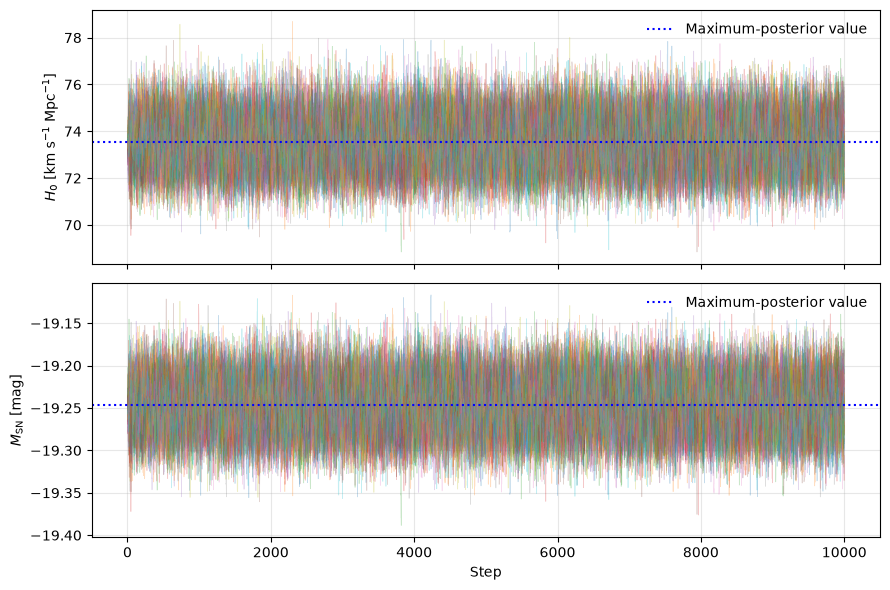

In [23]:
samples = sampler.get_chain()

assert samples.shape == (nsteps,nwalkers,ndim)

trace_labels = [
    r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]",
    r"$M_{\rm SN}$ [mag]",
]
best_values = [H0_best,M_SN_best]

fig, axes = plt.subplots(ndim,1,figsize=(9,6),sharex=True)

for parameter_index, ax in enumerate(axes):
    for walker in range(nwalkers):
        ax.plot(samples[:,walker,parameter_index],alpha=0.25,linewidth=0.5)

    ax.axhline(best_values[parameter_index],color="blue",linestyle=":",label="Maximum-posterior value")
    ax.set_ylabel(trace_labels[parameter_index])
    ax.grid(True,alpha=0.3)
    ax.legend(loc="upper right", frameon=False)

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

In [24]:
discard = 500

tau_full = sampler.get_autocorr_time()
tau_second_half = sampler.get_autocorr_time(discard=nsteps // 2)

ess = nwalkers * (nsteps - discard) / tau_full
chain_length_in_tau = nsteps / tau_full
relative_tau_difference = np.abs(tau_second_half - tau_full) / tau_full

assert tau_full.shape == (ndim,)
assert tau_second_half.shape == (ndim,)
assert np.isfinite(tau_full).all()
assert np.all(chain_length_in_tau > 50)

parameter_names = ["H0","M_SN"]

for name, tau, tau_half, relative_difference, n_eff, n_tau in zip(
    parameter_names,
    tau_full,
    tau_second_half,
    relative_tau_difference,
    ess,
    chain_length_in_tau,
):
    print(f"{name}:")
    print(f"  tau from full chain = {tau:.2f} steps")
    print(f"  tau from second half = {tau_half:.2f} steps")
    print(f"  relative tau difference = {relative_difference:.1%}")
    print(f"  chain length / tau = {n_tau:.1f}")
    print(f"  effective sample size = {n_eff:.0f}")

H0:
  tau from full chain = 30.52 steps
  tau from second half = 29.37 steps
  relative tau difference = 3.8%
  chain length / tau = 327.7
  effective sample size = 15564
M_SN:
  tau from full chain = 29.84 steps
  tau from second half = 28.77 steps
  relative tau difference = 3.6%
  chain length / tau = 335.2
  effective sample size = 15920


The trace plots and autocorrelation-time estimates are used together to assess convergence.

The full-chain and second-half estimates of $\tau$ should remain reasonably consistent. The quantity $N_{\mathrm{steps}}/\tau$ verifies that the run contains many autocorrelation times, while the effective sample size estimates how many approximately independent posterior samples are represented by the correlated chain.

We remove the first 500 steps as burn-in. The remaining samples are kept without thinning for posterior summaries. Thinning is used only to reduce the number of points displayed in the corner plot.

In [25]:
flat_samples = sampler.get_chain(discard=discard,flat=True)

expected_shape = ((nsteps - discard) * nwalkers,ndim)
assert flat_samples.shape == expected_shape
assert np.isfinite(flat_samples).all()

H0_samples = flat_samples[:,0]
M_SN_samples = flat_samples[:,1]

H0_q16, H0_q50, H0_q84 = np.percentile(H0_samples,[16,50,84])
M_SN_q16, M_SN_q50, M_SN_q84 = np.percentile(M_SN_samples,[16,50,84])

assert H0_q16 < H0_q50 < H0_q84
assert M_SN_q16 < M_SN_q50 < M_SN_q84

print("Flattened chain shape:",flat_samples.shape)
print(f"H0 = {H0_q50:.2f} +{H0_q84 - H0_q50:.2f} -{H0_q50 - H0_q16:.2f} km/s/Mpc")
print(f"M_SN = {M_SN_q50:.3f} +{M_SN_q84 - M_SN_q50:.3f} -{M_SN_q50 - M_SN_q16:.3f} mag")
print(f"Difference between MCMC median and GLS H0: {H0_q50 - H0_gls:.3f} km/s/Mpc")
print(f"Difference between MCMC median and GLS M_SN: {M_SN_q50 - M_SN_gls:.4f} mag")

Flattened chain shape: (475000, 2)
H0 = 73.55 +1.06 -1.03 km/s/Mpc
M_SN = -19.246 +0.030 -0.030 mag
Difference between MCMC median and GLS H0: 0.021 km/s/Mpc
Difference between MCMC median and GLS M_SN: 0.0007 mag


Samples used for the corner plot: (47500, 2)


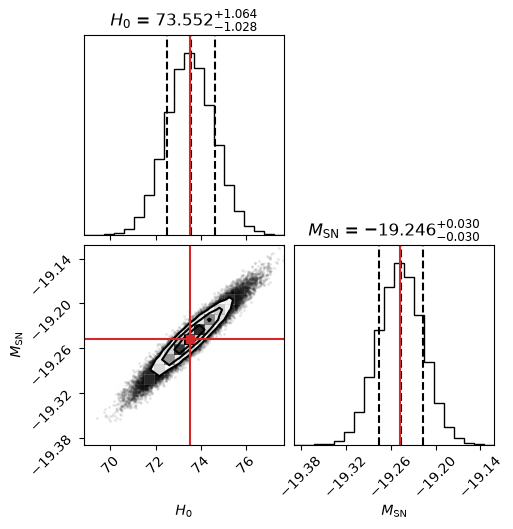

In [26]:
# Keep every tenth MCMC step from every walker for the figure only.
plot_samples = sampler.get_chain(discard=discard,thin=10,flat=True)

assert plot_samples.shape == (47500,ndim)

print("Samples used for the corner plot:",plot_samples.shape)

fig = corner.corner(
    plot_samples,
    labels=[r"$H_0$",r"$M_{\rm SN}$"],
    truths=[H0_gls,M_SN_gls],
    truth_color="C3",
    quantiles=[0.16,0.5,0.84],
    show_titles=True,
    title_fmt=".3f",
)

plt.show()

## 7. Additional-scatter robustness extension

The published statistical+systematic covariance already includes an intrinsic-scatter model. We therefore keep the two-parameter model as the baseline analysis.

As a separate robustness test, we introduce an additional unexplained scatter $\sigma_{\rm extra}$ beyond the published uncertainty budget:

$$
C_{\rm eff}
=
C_{\rm analysis}
+
\sigma_{\rm extra}^2 I.
$$

Here, $\sigma_{\rm extra}$ is measured in magnitudes, $I$ is the $N_{\rm analysis}\times N_{\rm analysis}$ identity matrix, and $C_{\rm eff}$ is measured in $\mathrm{mag}^2$.

The extended parameter vector is

$$
\theta_{\rm extra}
=
(H_0,M_{\rm SN},\sigma_{\rm extra}).
$$

When $\sigma_{\rm extra}=0$, the extended model reduces exactly to the baseline model.

This parameter is not interpreted as the intrinsic scatter of Type Ia supernovae. It represents only a possible independent dispersion in addition to all contributions already included in the published covariance.

We adopt a uniform prior

$$
0\leq\sigma_{\rm extra}\leq0.3\ \mathrm{mag}.
$$

Because the parameter is restricted to be non-negative, a positive posterior median does not by itself demonstrate a detection. The scientifically relevant result will be the maximum-posterior value and the 95% upper limit.

In [27]:
I_analysis = np.eye(n_analysis)

assert I_analysis.shape == C_analysis.shape

def log_prior_extra(theta):
    H0, M_SN, sigma_extra = theta

    if (
        50.0 < H0 < 90.0
        and -20.5 < M_SN < -18.0
        and 0.0 <= sigma_extra <= 0.3
    ):
        return 0.0

    return -np.inf

def log_likelihood_extra(theta,data,C_base,I):
    H0, M_SN, sigma_extra = theta

    # Reuse the two-parameter magnitude model.
    residuals = residual_vector((H0,M_SN),data)

    # Add the independent extra variance to the covariance diagonal.
    C_eff = C_base + sigma_extra**2 * I

    try:
        cho_eff, logdet_eff = factorize_covariance(C_eff)
    except np.linalg.LinAlgError:
        return -np.inf

    return gaussian_log_likelihood(residuals,cho_eff,logdet_eff)

def log_posterior_extra(theta,data,C_base,I):
    lp = log_prior_extra(theta)

    if not np.isfinite(lp):
        return -np.inf

    return lp + log_likelihood_extra(theta,data,C_base,I)

def neg_log_posterior_extra(theta,data,C_base,I):
    logp = log_posterior_extra(theta,data,C_base,I)

    if np.isfinite(logp):
        return -logp

    return 1e100

When $\sigma_{\rm extra}=0$,

$$
C_{\rm eff}=C_{\rm analysis},
$$

so the extended **likelihood** reduces exactly to the baseline likelihood.

In [28]:
# At sigma_extra = 0, the extended likelihood must reduce exactly to the baseline likelihood.

theta_zero_extra = np.array([H0_best, M_SN_best, 0.0])

logL_baseline = log_likelihood((H0_best, M_SN_best),analysis_data,cho_C_analysis,logdet_C_analysis)

logL_extra_zero = log_likelihood_extra(theta_zero_extra,analysis_data,C_analysis,I_analysis)

assert np.isclose(logL_extra_zero,logL_baseline,rtol=0.0,atol=1e-10)

print(f"Log-likelihood difference at sigma_extra = 0: {logL_extra_zero - logL_baseline:.3e}")

initial_guess_extra = np.array([H0_best, M_SN_best, 0.01])
bounds_extra = (
    (50.0, 90.0),
    (-20.5, -18.0),
    (0.0, 0.3),)

result_extra = minimize(
    neg_log_posterior_extra,
    initial_guess_extra,
    args=(analysis_data, C_analysis, I_analysis),
    bounds=bounds_extra,
    method="L-BFGS-B",)

assert result_extra.success, result_extra.message
assert np.isfinite(result_extra.x).all()

H0_best_extra, M_SN_best_extra, sigma_extra_best = result_extra.x

print(f"H0 extended MAP: {H0_best_extra:.6f} km/s/Mpc")
print(f"M_SN extended MAP: {M_SN_best_extra:.6f} mag")
print(f"sigma_extra MAP: {sigma_extra_best:.6f} mag")
print("Optimizer success:", result_extra.message)
print(f"Log posterior at extended MAP: {-result_extra.fun:.6f}")

Log-likelihood difference at sigma_extra = 0: 0.000e+00
H0 extended MAP: 73.528936 km/s/Mpc
M_SN extended MAP: -19.246922 mag
sigma_extra MAP: 0.000000 mag
Optimizer success: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Log posterior at extended MAP: 233.881153


### 7.1 MCMC sampling of the additional-scatter extension

We now sample the extended posterior

$$
p(H_0,M_{\rm SN},\sigma_{\rm extra}\mid\mathrm{data}).
$$

The maximum-posterior solution lies at the physical boundary $\sigma_{\rm extra}=0$. To avoid initializing all walkers exactly on this boundary, their initial values of $\sigma_{\rm extra}$ are drawn from a small positive interval.

The MCMC uses the same number of walkers and steps as the baseline analysis. Separate variable names are used so that the baseline chain and its results are not overwritten.

Because $C_{\rm eff}$ depends on $\sigma_{\rm extra}$, its Cholesky factorization and log-determinant must be recalculated for every likelihood evaluation. This makes the extended MCMC slower than the baseline run.

In [29]:
ndim_extra = 3

# Initialize H0 and M_SN close to the extended MAP.
rng_extra = np.random.default_rng(EXTRA_MCMC_SEED)
p0_extra = np.empty((nwalkers,ndim_extra))

p0_extra[:,:2] = (
    np.array([H0_best_extra,M_SN_best_extra])
    + np.array([0.1,0.01]) * rng_extra.normal(size=(nwalkers,2))
)

# Start sigma_extra at small positive values, away from the boundary.
p0_extra[:,2] = rng_extra.uniform(0.001,0.020,size=nwalkers)

assert p0_extra.shape == (nwalkers,ndim_extra)
assert np.all(p0_extra[:,2] > 0.0)
assert all(np.isfinite(log_prior_extra(position)) for position in p0_extra)

np.random.seed(EXTRA_MCMC_SEED)

sampler_extra = emcee.EnsembleSampler(
    nwalkers,
    ndim_extra,
    log_posterior_extra,
    args=(analysis_data,C_analysis,I_analysis),
)

_ = sampler_extra.run_mcmc(p0_extra,nsteps,progress=True)

samples_extra = sampler_extra.get_chain()
log_prob_samples_extra = sampler_extra.get_log_prob()

assert samples_extra.shape == (nsteps,nwalkers,ndim_extra)
assert log_prob_samples_extra.shape == (nsteps,nwalkers)
assert np.isfinite(samples_extra).all()
assert np.isfinite(log_prob_samples_extra).all()

print("Raw extended chain shape:",samples_extra.shape)
print("Raw extended log-probability shape:",log_prob_samples_extra.shape)

100%|██████████| 10000/10000 [12:11<00:00, 13.67it/s]

Raw extended chain shape: (10000, 50, 3)
Raw extended log-probability shape: (10000, 50)


### 7.2 Diagnostics and upper limit on additional scatter

Before interpreting the extended posterior, we verify the acceptance fraction, trace plots, autocorrelation times and effective sample sizes.

The posterior of $\sigma_{\rm extra}$ is restricted to

$$
\sigma_{\rm extra}\geq0.
$$

Consequently, its posterior can have a positive median even if its maximum is at zero. A positive median is therefore not sufficient evidence for additional scatter.

The relevant quantities are:

- the maximum-posterior value;
- the 16th, 50th and 84th percentiles;
- the one-sided 95% upper limit.

The upper limit is defined by

$$
P\left(\sigma_{\rm extra}<\sigma_{\rm extra}^{95\%}\mid\mathrm{data}\right)
=
0.95.
$$

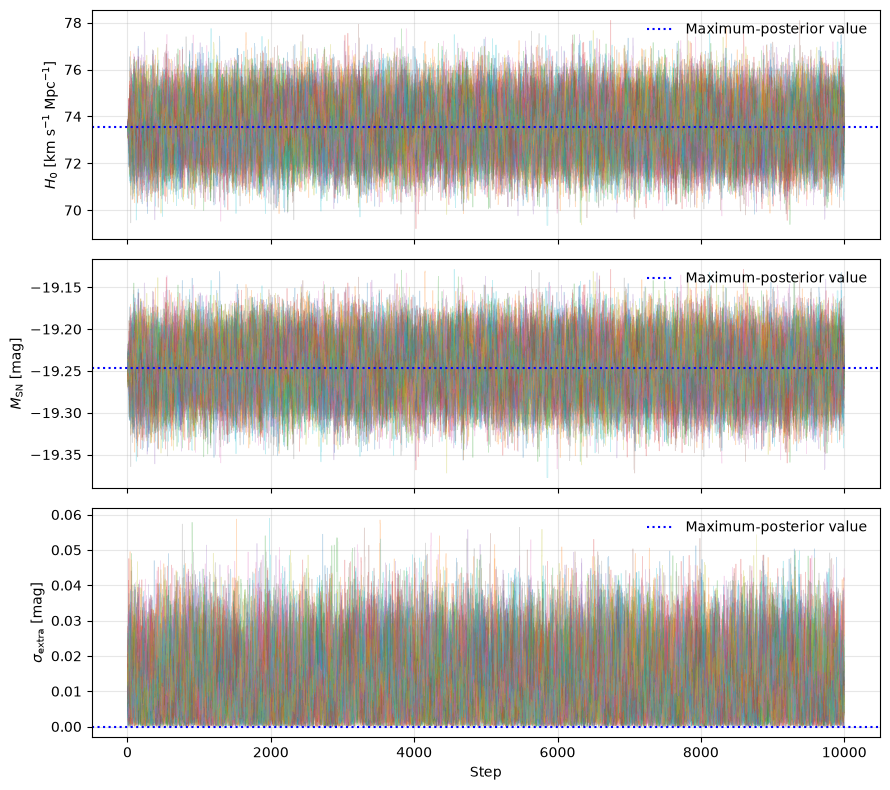

Mean acceptance fraction: 0.619


In [30]:
mean_acceptance_extra = np.mean(sampler_extra.acceptance_fraction)
samples_extra = sampler_extra.get_chain()

assert np.isfinite(mean_acceptance_extra)
assert 0.0 < mean_acceptance_extra < 1.0
assert samples_extra.shape == (nsteps,nwalkers,ndim_extra)

trace_labels_extra = [
    r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]",
    r"$M_{\rm SN}$ [mag]",
    r"$\sigma_{\rm extra}$ [mag]",
]
best_values_extra = [H0_best_extra,M_SN_best_extra,sigma_extra_best]

fig, axes = plt.subplots(ndim_extra,1,figsize=(9,8),sharex=True)

for parameter_index, ax in enumerate(axes):
    for walker in range(nwalkers):
        ax.plot(samples_extra[:,walker,parameter_index],alpha=0.25,linewidth=0.5)

    ax.axhline(best_values_extra[parameter_index],color="blue",linestyle=":",label="Maximum-posterior value")
    ax.set_ylabel(trace_labels_extra[parameter_index])
    ax.grid(True,alpha=0.3)
    ax.legend(loc="upper right", frameon=False)

axes[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

print(f"Mean acceptance fraction: {mean_acceptance_extra:.3f}")

In [31]:
discard_extra = 500

tau_full_extra = sampler_extra.get_autocorr_time()
tau_second_half_extra = sampler_extra.get_autocorr_time(discard=nsteps // 2)

ess_extra = nwalkers * (nsteps - discard_extra) / tau_full_extra
chain_length_in_tau_extra = nsteps / tau_full_extra
relative_tau_difference_extra = np.abs(tau_second_half_extra - tau_full_extra) / tau_full_extra

assert tau_full_extra.shape == (ndim_extra,)
assert tau_second_half_extra.shape == (ndim_extra,)
assert np.isfinite(tau_full_extra).all()
assert np.all(chain_length_in_tau_extra > 50)

parameter_names_extra = ["H0","M_SN","sigma_extra"]

for name, tau, tau_half, relative_difference, n_eff, n_tau in zip(
    parameter_names_extra,
    tau_full_extra,
    tau_second_half_extra,
    relative_tau_difference_extra,
    ess_extra,
    chain_length_in_tau_extra,
):
    print(f"{name}:")
    print(f"  tau from full chain = {tau:.2f} steps")
    print(f"  tau from second half = {tau_half:.2f} steps")
    print(f"  relative tau difference = {relative_difference:.1%}")
    print(f"  chain length / tau = {n_tau:.1f}")
    print(f"  effective sample size = {n_eff:.0f}")

H0:
  tau from full chain = 41.80 steps
  tau from second half = 39.37 steps
  relative tau difference = 5.8%
  chain length / tau = 239.3
  effective sample size = 11364
M_SN:
  tau from full chain = 42.92 steps
  tau from second half = 40.29 steps
  relative tau difference = 6.1%
  chain length / tau = 233.0
  effective sample size = 11066
sigma_extra:
  tau from full chain = 43.39 steps
  tau from second half = 45.30 steps
  relative tau difference = 4.4%
  chain length / tau = 230.5
  effective sample size = 10947


In [32]:
flat_samples_extra = sampler_extra.get_chain(discard=discard_extra,flat=True)

expected_shape_extra = ((nsteps - discard_extra) * nwalkers,ndim_extra)
assert flat_samples_extra.shape == expected_shape_extra
assert np.isfinite(flat_samples_extra).all()

H0_samples_extra = flat_samples_extra[:,0]
M_SN_samples_extra = flat_samples_extra[:,1]
sigma_extra_samples = flat_samples_extra[:,2]

assert np.all(sigma_extra_samples >= 0.0)

H0_extra_q16, H0_extra_q50, H0_extra_q84 = np.percentile(H0_samples_extra,[16,50,84])
M_SN_extra_q16, M_SN_extra_q50, M_SN_extra_q84 = np.percentile(M_SN_samples_extra,[16,50,84])
sigma_extra_q16, sigma_extra_q50, sigma_extra_q84 = np.percentile(sigma_extra_samples,[16,50,84])
sigma_extra_q95 = np.percentile(sigma_extra_samples,95)

print("Flattened extended chain shape:",flat_samples_extra.shape)

print(
    f"H0 = {H0_extra_q50:.2f} "
    f"+{H0_extra_q84 - H0_extra_q50:.2f} "
    f"-{H0_extra_q50 - H0_extra_q16:.2f} km/s/Mpc"
)

print(
    f"M_SN = {M_SN_extra_q50:.3f} "
    f"+{M_SN_extra_q84 - M_SN_extra_q50:.3f} "
    f"-{M_SN_extra_q50 - M_SN_extra_q16:.3f} mag"
)

print(
    f"sigma_extra median = {sigma_extra_q50:.4f} "
    f"+{sigma_extra_q84 - sigma_extra_q50:.4f} "
    f"-{sigma_extra_q50 - sigma_extra_q16:.4f} mag"
)

print(f"sigma_extra MAP = {sigma_extra_best:.6f} mag")
print(f"sigma_extra 95% upper limit = {sigma_extra_q95:.4f} mag")

Flattened extended chain shape: (475000, 3)
H0 = 73.53 +1.04 -1.03 km/s/Mpc
M_SN = -19.247 +0.029 -0.029 mag
sigma_extra median = 0.0109 +0.0107 -0.0075 mag
sigma_extra MAP = 0.000000 mag
sigma_extra 95% upper limit = 0.0290 mag


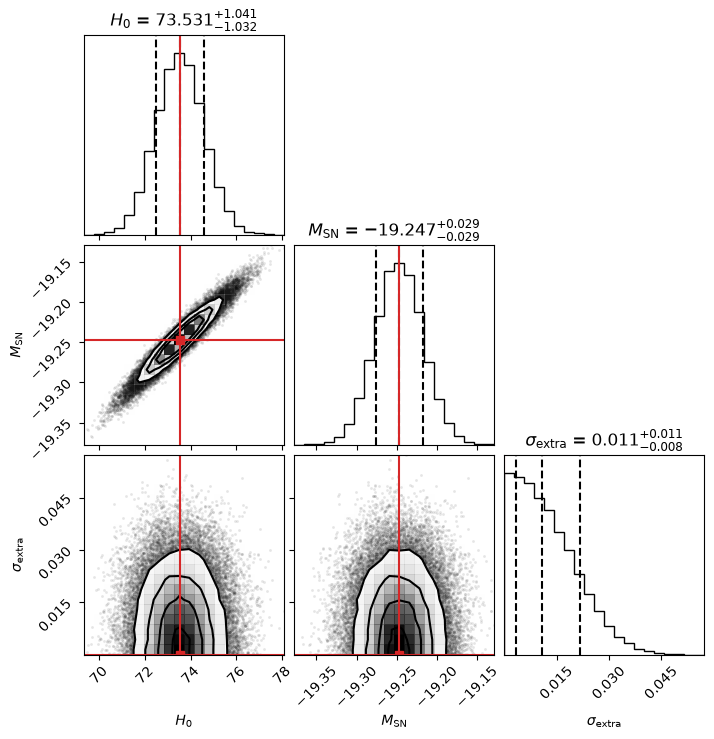

In [33]:
# Keep every tenth MCMC step from every walker for the figure only.
plot_samples_extra = sampler_extra.get_chain(discard=discard_extra,thin=10,flat=True)

assert plot_samples_extra.shape == (47500,ndim_extra)

fig = corner.corner(
    plot_samples_extra,
    labels=[r"$H_0$",r"$M_{\rm SN}$",r"$\sigma_{\rm extra}$"],
    truths=[H0_best_extra,M_SN_best_extra,sigma_extra_best],
    truth_color="C3",
    quantiles=[0.16,0.5,0.84],
    show_titles=True,
    title_fmt=".3f",
)

plt.show()

## 8. Baseline residuals and goodness of fit

We now assess the goodness of fit of the two-parameter baseline model.

The raw residual vector is

$$
\mathbf r
=
\mathbf m_{\rm obs}
-
\mathbf m_{\rm model}.
$$

Because the observational uncertainties are correlated, the raw residuals are not expected to be independent. We therefore use the Cholesky decomposition

$$
C_{\rm analysis}=LL^\top
$$

to construct the whitened residuals

$$
\mathbf r_{\rm white}
=
L^{-1}\mathbf r.
$$

The raw residuals have shape $(N_{\rm analysis},)$ and are measured in magnitudes. The whitened residuals have the same shape but are dimensionless.

If the parameters were fixed at their true values, whitening would transform
Gaussian noise with covariance $C_{\rm analysis}$ into a vector distributed as

$$
\mathcal N(0,I).
$$

After fitting two parameters to the same data, however, the whitened residuals
are projected onto an $(N_{\rm analysis}-2)$-dimensional residual subspace and
are therefore not strictly independent standard-normal variables.

Their scale, histogram and Q–Q behaviour nevertheless provide useful
qualitative diagnostics, while the global goodness of fit is quantified using $\chi^2$ with $\nu=N_{\rm analysis}-2$ degrees of freedom.

The generalized chi-square can also be written as

$$
\chi^2
=
\mathbf r^\top C_{\rm analysis}^{-1}\mathbf r
=
\mathbf r_{\rm white}^\top\mathbf r_{\rm white}.
$$

With $N_{\rm analysis}=354$ observations and two fitted parameters, the number of degrees of freedom is

$$
\nu=354-2=352.
$$

The upper-tail goodness-of-fit probability is

$$
p
=
P\left(\chi^2_\nu\geq\chi^2_{\rm observed}\right).
$$

In [34]:
from scipy.linalg import solve_triangular
from scipy.stats import chi2 as chi2_distribution

# Reuse the baseline residuals and Cholesky factor already calculated.
residuals_baseline = residuals_best
L_analysis = np.tril(cho_C_analysis[0])

whitened_residuals = solve_triangular(
    L_analysis,
    residuals_baseline,
    lower=True,
    check_finite=False,
)

chi2_whitened = whitened_residuals @ whitened_residuals
dof_baseline = degrees_of_freedom
reduced_chi2_baseline = chi2_whitened / dof_baseline
p_value_baseline = chi2_distribution.sf(chi2_whitened,dof_baseline)

mean_whitened = np.mean(whitened_residuals)
std_whitened = np.std(whitened_residuals,ddof=1)

assert residuals_baseline.shape == (n_analysis,)
assert L_analysis.shape == C_analysis.shape
assert whitened_residuals.shape == (n_analysis,)
assert np.isfinite(whitened_residuals).all()
assert np.all(np.diag(L_analysis) > 0.0)
assert np.isclose(chi2_whitened,chi2_best,rtol=0.0,atol=1e-8)
assert 0.0 <= p_value_baseline <= 1.0

print(f"Chi-square from whitened residuals: {chi2_whitened:.6f}")
print(f"Degrees of freedom: {dof_baseline}")
print(f"Reduced chi-square: {reduced_chi2_baseline:.6f}")
print(f"Upper-tail p-value: {p_value_baseline:.6f}")
print(f"Mean whitened residual: {mean_whitened:.6f}")
print(f"Standard deviation of whitened residuals: {std_whitened:.6f}")

Chi-square from whitened residuals: 299.906071
Degrees of freedom: 352
Reduced chi-square: 0.852006
Upper-tail p-value: 0.979528
Mean whitened residual: 0.018916
Standard deviation of whitened residuals: 0.921539


### 8.1 Residual diagnostics

The first panel shows the raw residuals of the Hubble-flow supernovae as a function of $z_{\rm HD}$. Only the Hubble-flow sample is shown because the calibrator model uses Cepheid distances rather than redshift.

The second panel shows the whitened residuals in analysis-row order. Whitening combines the original residuals through $L^{-1}$, so an individual whitened component should not be interpreted as the residual of one supernova at a particular redshift.

If the baseline model and the published covariance are adequate, the whitened residuals should fluctuate around zero with a typical amplitude of order unity.

The histogram and Q–Q plot provide qualitative checks of compatibility with a standard normal distribution $\mathcal N(0,1)$. The whitened residuals are dimensionless.

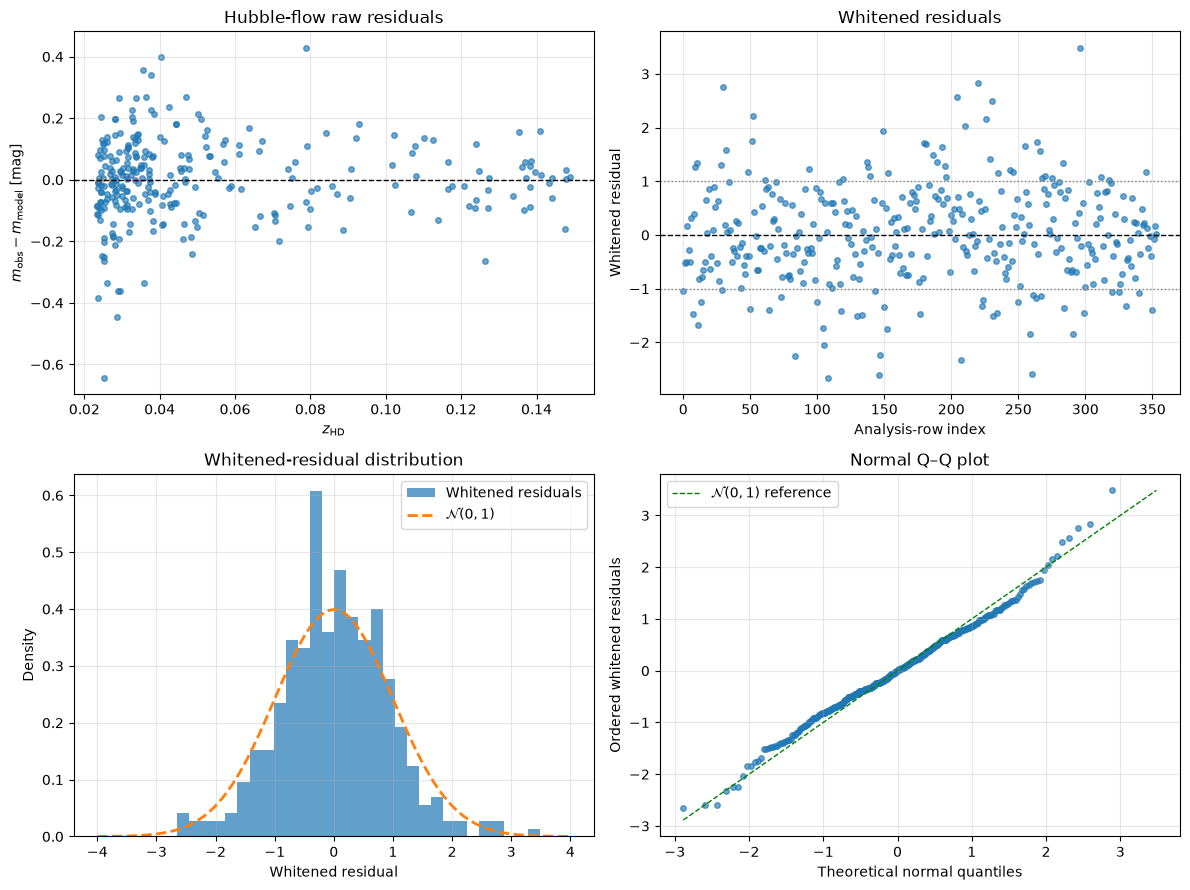

In [35]:
from scipy.stats import probplot

# Select Hubble-flow objects for the redshift-dependent diagnostic.
is_hf_residual = analysis_data["role"].eq("HUBBLE_FLOW").to_numpy()
z_hd_residual = analysis_data.loc[is_hf_residual,"zHD"].to_numpy()
raw_residuals_hf = residuals_baseline[is_hf_residual]

# Whitened components are displayed in analysis-row order.
analysis_row = np.arange(n_analysis)

assert z_hd_residual.shape == raw_residuals_hf.shape
assert analysis_row.shape == whitened_residuals.shape
assert np.isfinite(z_hd_residual).all()
assert np.isfinite(raw_residuals_hf).all()

fig, axes = plt.subplots(2,2,figsize=(12,9))

# Raw residuals as a function of the model redshift.
axes[0,0].scatter(z_hd_residual,raw_residuals_hf,s=16,alpha=0.65)
axes[0,0].axhline(0.0,color="black",linestyle="--",linewidth=1)
axes[0,0].set_xlabel(r"$z_{\rm HD}$")
axes[0,0].set_ylabel(r"$m_{\rm obs}-m_{\rm model}$ [mag]")
axes[0,0].set_title("Hubble-flow raw residuals")
axes[0,0].grid(True,alpha=0.3)

# Whitened residuals in covariance-matrix row order.
axes[0,1].scatter(analysis_row,whitened_residuals,s=16,alpha=0.65)
axes[0,1].axhline(0.0,color="black",linestyle="--",linewidth=1)
axes[0,1].axhline(1.0,color="grey",linestyle=":",linewidth=1)
axes[0,1].axhline(-1.0,color="grey",linestyle=":",linewidth=1)
axes[0,1].set_xlabel("Analysis-row index")
axes[0,1].set_ylabel("Whitened residual")
axes[0,1].set_title("Whitened residuals")
axes[0,1].grid(True,alpha=0.3)

# Distribution compared with a standard normal density.
axes[1,0].hist(
    whitened_residuals,
    bins=30,
    density=True,
    alpha=0.7,
    label="Whitened residuals",
)

x_normal = np.linspace(-4,4,400)
standard_normal_pdf = np.exp(-0.5 * x_normal**2) / np.sqrt(2 * np.pi)

axes[1,0].plot(
    x_normal,
    standard_normal_pdf,
    linestyle="--",
    linewidth=2,
    label=r"$\mathcal{N}(0,1)$",
)

axes[1,0].set_xlabel("Whitened residual")
axes[1,0].set_ylabel("Density")
axes[1,0].set_title("Whitened-residual distribution")
axes[1,0].legend()
axes[1,0].grid(True,alpha=0.3)

# Quantiles compared directly with standard-normal quantiles.
theoretical_quantiles, ordered_residuals = probplot(
    whitened_residuals,
    dist="norm",
    fit=False,
)

axes[1,1].scatter(theoretical_quantiles,ordered_residuals,s=16,alpha=0.65)

qq_min = min(theoretical_quantiles.min(),ordered_residuals.min())
qq_max = max(theoretical_quantiles.max(),ordered_residuals.max())

axes[1,1].plot(
    [qq_min,qq_max],
    [qq_min,qq_max],
    color="green",
    linestyle="--",
    linewidth=1,
    label=r"$\mathcal{N}(0,1)$ reference",
)

axes[1,1].set_xlabel("Theoretical normal quantiles")
axes[1,1].set_ylabel("Ordered whitened residuals")
axes[1,1].set_title("Normal Q–Q plot")
axes[1,1].legend()
axes[1,1].grid(True,alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Robustness tests

### 9.1 Statistical-only versus statistical-plus-systematic covariance

The baseline analysis uses the full published `STAT+SYS` covariance matrix, which includes both statistical and systematic uncertainties.

As a robustness test, we repeat the analytic GLS fit using the `STATONLY` covariance while keeping the data selection and magnitude model unchanged.

The published `STATONLY` matrix is however not diagonal: it still contains
off-diagonal intrinsic-scatter components when multiple light curves
correspond to the same supernova. The test therefore removes the published
systematic covariance terms, not all correlations.

For each covariance matrix $C$, the GLS estimator is

$$
\hat{\boldsymbol{\beta}}
=
(X^\top C^{-1}X)^{-1}X^\top C^{-1}\mathbf y,
$$

with

$$
\boldsymbol{\beta}
=
(M_{\rm SN},h),
\qquad
h=-5\log_{10}H_0.
$$

The comparison tests how the inclusion of systematic covariance affects the central value and uncertainty of $H_0$. The `STAT+SYS` result remains the baseline scientific result.

In [36]:
statonly_cov_url = f"{BASE_URL}/Pantheon%2BSH0ES_STATONLY.cov"

statonly_bytes = download_bytes(statonly_cov_url)
statonly_sha256 = sha256_digest(statonly_bytes)
statonly_raw = np.loadtxt(BytesIO(statonly_bytes))

print("STATONLY covariance SHA-256:", statonly_sha256)

EXPECTED_STATONLY_SHA256 = ("9f177129a332735d3637affd20054080d5260815f3ca0809120c05b2c902297f")

assert statonly_sha256 == EXPECTED_STATONLY_SHA256, ("Unexpected SHA-256 hash for the STATONLY covariance")

statonly_N_header = statonly_raw[0]
assert np.isfinite(statonly_N_header)
assert statonly_N_header.is_integer()

statonly_N = int(statonly_N_header)
statonly_values = statonly_raw[1:]

assert statonly_N == N
assert statonly_values.size == N**2

C_statonly_full_raw = statonly_values.reshape(N,N)
max_asym_statonly = np.max(np.abs(C_statonly_full_raw - C_statonly_full_raw.T))

assert np.isfinite(C_statonly_full_raw).all()
assert np.allclose(
    C_statonly_full_raw,
    C_statonly_full_raw.T,
    rtol=0.0,
    atol=symmetry_atol,
)

C_statonly_full = 0.5 * (C_statonly_full_raw + C_statonly_full_raw.T)
C_statonly_analysis = C_statonly_full[np.ix_(analysis_indexes,analysis_indexes)]

assert C_statonly_analysis.shape == C_analysis.shape
assert np.array_equal(C_statonly_analysis,C_statonly_analysis.T)
assert np.all(np.diag(C_statonly_analysis) > 0.0)

covariance_comparison = pd.DataFrame({
    "STAT+SYS": fit_distance_ladder_gls(
        y_gls,
        X_gls,
        C_analysis,
    ),
    "STATONLY": fit_distance_ladder_gls(
        y_gls,
        X_gls,
        C_statonly_analysis,
    ),
}).T

assert np.isclose(
    covariance_comparison.loc["STAT+SYS","H0"],
    H0_gls,
    rtol=0.0,
    atol=1e-8,
)

display(covariance_comparison.round(6))

delta_H0_statonly = (
    covariance_comparison.loc["STATONLY","H0"]
    - covariance_comparison.loc["STAT+SYS","H0"]
)

relative_sigma_change = (
    covariance_comparison.loc["STATONLY","sigma_H0"]
    / covariance_comparison.loc["STAT+SYS","sigma_H0"]
    - 1.0
)

print(f"STATONLY - STAT+SYS shift in H0: {delta_H0_statonly:.6f} km/s/Mpc")
print(f"Relative change in H0 uncertainty: {relative_sigma_change:.2%}")
print(f"Maximum STATONLY covariance asymmetry before symmetrization: {max_asym_statonly:.3e} mag^2")

STATONLY covariance SHA-256: 9f177129a332735d3637affd20054080d5260815f3ca0809120c05b2c902297f


,H0,sigma_H0,M_SN,sigma_M_SN,chi2,reduced_chi2
STAT+SYS,73.528966,1.048262,-19.246921,0.029855,299.906071,0.852006
STATONLY,73.367092,1.023429,-19.247853,0.029205,307.077855,0.872380


STATONLY - STAT+SYS shift in H0: -0.161874 km/s/Mpc
Relative change in H0 uncertainty: -2.37%
Maximum STATONLY covariance asymmetry before symmetrization: 3.000e-08 mag^2


### 9.2 Full covariance versus diagonal approximation

To isolate the effect of correlations, we construct a diagonal covariance matrix from the diagonal of the baseline `STAT+SYS` covariance:

$$
C_{\rm diagonal}
=
\operatorname{diag}
\left(
C_{11},C_{22},\ldots,C_{NN}
\right).
$$

This approximation preserves the published variance of every selected observation but sets all cross-covariances to zero.

The comparison therefore changes only the correlation structure. It does not use the visualization-only `m_b_corr_err_DIAG` or `MU_SH0ES_ERR_DIAG` columns.

The diagonal result is presented only as a methodological demonstration. The full `STAT+SYS` covariance remains the scientifically appropriate baseline.

In [37]:
# Preserve the variances but remove every off-diagonal covariance.
C_diagonal_analysis = np.diag(np.diag(C_analysis))

assert C_diagonal_analysis.shape == C_analysis.shape
assert np.array_equal(np.diag(C_diagonal_analysis),np.diag(C_analysis))
assert np.count_nonzero(C_diagonal_analysis) == n_analysis
assert np.all(np.diag(C_diagonal_analysis) > 0.0)

# Reuse the GLS function defined in the analytic baseline section.
covariance_comparison.loc["DIAGONAL STAT+SYS"] = fit_distance_ladder_gls(
    y_gls,
    X_gls,
    C_diagonal_analysis,
)

display(covariance_comparison.round(6))

delta_H0_diagonal = (
    covariance_comparison.loc["DIAGONAL STAT+SYS","H0"]
    - covariance_comparison.loc["STAT+SYS","H0"]
)

relative_sigma_change_diagonal = (
    covariance_comparison.loc["DIAGONAL STAT+SYS","sigma_H0"]
    / covariance_comparison.loc["STAT+SYS","sigma_H0"]
    - 1.0
)

print(f"Diagonal - full shift in H0: {delta_H0_diagonal:.6f} km/s/Mpc")
print(f"Relative change in H0 uncertainty: {relative_sigma_change_diagonal:.2%}")

,H0,sigma_H0,M_SN,sigma_M_SN,chi2,reduced_chi2
STAT+SYS,73.528966,1.048262,-19.246921,0.029855,299.906071,0.852006
STATONLY,73.367092,1.023429,-19.247853,0.029205,307.077855,0.872380
DIAGONAL STAT+SYS,73.495590,0.657654,-19.244663,0.017682,297.352805,0.844752


Diagonal - full shift in H0: -0.033376 km/s/Mpc
Relative change in H0 uncertainty: -37.26%


### 9.3 Sensitivity to the distance-redshift model

We now test the sensitivity of the inferred Hubble constant to the adopted distance-redshift relation.

The selected observations, full `STAT+SYS` covariance matrix, redshift-frame treatment and two fitted parameters remain unchanged. Only the Hubble-flow luminosity-distance model is varied.

We compare:

1. a first-order expansion,

$$
d_L^{(1)}
=
\frac{c z_{\rm HD}}{H_0}
\frac{1+z_{\rm HEL}}{1+z_{\rm HD}};
$$

2. the baseline third-order cosmographic expansion,

$$
d_L^{\rm cosmo}
=
\frac{c z_{\rm HD}}{H_0}
\left[
1
+
\frac{1-q_0}{2}z_{\rm HD}
-
\frac{1-q_0-3q_0^2+j_0}{6}z_{\rm HD}^2
\right]
\frac{1+z_{\rm HEL}}{1+z_{\rm HD}},
$$

with

$$
q_0=-0.55,
\qquad
j_0=1;
$$

3. the exact luminosity distance in a spatially flat $\Lambda$CDM model with fixed

$$
\Omega_m=0.3.
$$

For the exact flat-$\Lambda$CDM benchmark,

$$
d_L^{\Lambda{\rm CDM}}
=
(1+z_{\rm HEL})\frac{c}{H_0}
\int_0^{z_{\rm HD}}
\frac{dz'}
{\sqrt{\Omega_m(1+z')^3+1-\Omega_m}}.
$$

The exact model is not used to infer $\Omega_m$ and does not introduce an additional fitted parameter. Its purpose is to validate the accuracy of the cosmographic truncation over the redshift range of the published Hubble-flow sample.

All three distances scale as $H_0^{-1}$, so the same two-parameter GLS estimator can be used.

In [38]:
omega_m_lcdm = 0.3


def distance_modulus_flat_lcdm(z_hd, z_hel, H0, omega_m):
    """Exact flat-LambdaCDM distance modulus for one-dimensional arrays."""
    z_hd = np.asarray(z_hd, dtype=float)
    z_hel = np.asarray(z_hel, dtype=float)

    assert z_hd.ndim == 1
    assert z_hd.shape == z_hel.shape
    assert np.all(z_hd > 0.0)
    assert np.all(z_hel > 0.0)
    assert H0 > 0.0
    assert 0.0 < omega_m < 1.0

    omega_lambda = 1.0 - omega_m

    def inverse_E(z):
        return 1.0 / np.sqrt(omega_m * (1.0 + z)**3 + omega_lambda)

    integration_results = np.array([
        quad(
            inverse_E,
            0.0,
            z_max,
            epsabs=1e-12,
            epsrel=1e-12,
        )
        for z_max in z_hd
    ])

    comoving_integrals = integration_results[:, 0]
    integration_errors = integration_results[:, 1]

    assert np.isfinite(comoving_integrals).all()
    assert np.max(integration_errors) < 1e-10

    # Standard luminosity distance evaluated using zHD.
    d_L_z_hd = (
        (c_km_s / H0)
        * (1.0 + z_hd)
        * comoving_integrals
    )

    # Apply exactly the same redshift-frame correction as in the baseline.
    redshift_frame_factor = (
        (1.0 + z_hel)
        / (1.0 + z_hd)
    )

    d_L_corrected = d_L_z_hd * redshift_frame_factor

    return distance_modulus_from_dL(d_L_corrected)


# First-order model evaluated at H0 = 1 km/s/Mpc.
d_L_first_order_H0_one = (
    c_km_s
    * z_hd_hf
    * (1.0 + z_hel_hf)
    / (1.0 + z_hd_hf)
)

mu_first_order_H0_one = distance_modulus_from_dL(
    d_L_first_order_H0_one
)

# Reuse the cosmographic distance moduli already computed for the baseline.
mu_cosmography_H0_one = known_term[is_hf_gls].copy()

# Exact flat-LambdaCDM benchmark.
mu_lcdm_H0_one = distance_modulus_flat_lcdm(
    z_hd_hf,
    z_hel_hf,
    H0=1.0,
    omega_m=omega_m_lcdm,
)

n_hubble_flow_gls = np.count_nonzero(is_hf_gls)

for mu_model in (
    mu_first_order_H0_one,
    mu_cosmography_H0_one,
    mu_lcdm_H0_one,
):
    assert mu_model.shape == (n_hubble_flow_gls,)
    assert np.isfinite(mu_model).all()

m_b_analysis = analysis_data["m_b_corr"].to_numpy()

known_term_first_order = known_term.copy()
known_term_first_order[is_hf_gls] = mu_first_order_H0_one
y_gls_first_order = m_b_analysis - known_term_first_order

known_term_lcdm = known_term.copy()
known_term_lcdm[is_hf_gls] = mu_lcdm_H0_one
y_gls_lcdm = m_b_analysis - known_term_lcdm

assert y_gls_first_order.shape == y_gls.shape
assert y_gls_lcdm.shape == y_gls.shape
assert np.isfinite(y_gls_first_order).all()
assert np.isfinite(y_gls_lcdm).all()

In [39]:
cosmography_label = "Cosmography (through z^3)"

model_comparison = pd.DataFrame({
    "First-order expansion": fit_distance_ladder_gls(
        y_gls_first_order,
        X_gls,
        C_analysis,
    ),
    cosmography_label: fit_distance_ladder_gls(
        y_gls,
        X_gls,
        C_analysis,
    ),
    "Flat LambdaCDM (exact)": fit_distance_ladder_gls(
        y_gls_lcdm,
        X_gls,
        C_analysis,
    ),
}).T

model_comparison["delta_H0_vs_cosmography"] = (
    model_comparison["H0"]
    - model_comparison.loc[cosmography_label, "H0"]
)

model_comparison["delta_chi2_vs_cosmography"] = (
    model_comparison["chi2"]
    - model_comparison.loc[cosmography_label, "chi2"]
)

assert np.isclose(
    model_comparison.loc[cosmography_label, "H0"],
    H0_gls,
    rtol=0.0,
    atol=1e-8,
)

assert np.isclose(
    model_comparison.loc[cosmography_label, "chi2"],
    chi2_gls,
    rtol=0.0,
    atol=1e-8,
)

max_cosmography_lcdm_mu_difference = np.max(
    np.abs(mu_cosmography_H0_one - mu_lcdm_H0_one)
)

display(model_comparison[[
    "H0",
    "sigma_H0",
    "M_SN",
    "sigma_M_SN",
    "chi2",
    "reduced_chi2",
    "delta_H0_vs_cosmography",
    "delta_chi2_vs_cosmography",
]].round(6))

print(
    "Maximum |mu_cosmography - mu_LambdaCDM|: "
    f"{max_cosmography_lcdm_mu_difference:.6e} mag"
)

,H0,sigma_H0,M_SN,sigma_M_SN,chi2,reduced_chi2,delta_H0_vs_cosmography,delta_chi2_vs_cosmography
First-order expansion,70.573565,1.006128,-19.239699,0.029855,332.587421,0.944851,-2.955401,32.681350
Cosmography (through z^3),73.528966,1.048262,-19.246921,0.029855,299.906071,0.852006,0.000000,0.000000
Flat LambdaCDM (exact),73.529458,1.048269,-19.246923,0.029855,299.910773,0.852019,0.000492,0.004702


Maximum |mu_cosmography - mu_LambdaCDM|: 1.084591e-04 mag


The first-order expansion gives

$$
H_0=70.574\pm1.006\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

corresponding to a shift of

$$
\Delta H_0=-2.955\ \mathrm{km\,s^{-1}\,Mpc^{-1}}
$$

and an increase of $32.68$ in $\chi^2$ relative to the baseline cosmographic model.

Because the observations, covariance matrix and number of fitted parameters are identical, this comparison shows that the first-order distance-redshift relation is not sufficiently accurate for the precision targeted here.

By contrast, the exact flat-$\Lambda$CDM calculation changes $H_0$ by only

$$
4.9\times10^{-4}\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

while the maximum difference in distance modulus is

$$
\max|\mu_{\rm cosmo}-\mu_{\Lambda{\rm CDM}}|
=
1.08\times10^{-4}\ \mathrm{mag}.
$$

The third-order cosmographic truncation is therefore fully adequate over the redshift range of the selected Hubble-flow sample. It remains the baseline because it achieves this accuracy without requiring a complete cosmological model.

### 9.4 Sensitivity to the fixed deceleration parameter

The baseline cosmographic model fixes

$$
q_0=-0.55,
\qquad
j_0=1.
$$

Although the selected Hubble-flow sample lies at low redshift, a precise inference of $H_0$ retains a small dependence on the assumed recent expansion history.

We therefore repeat the GLS fit with

$$
q_0=-0.52,
\qquad
j_0=1,
$$

while keeping the selected observations, full `STAT+SYS` covariance matrix and two fitted parameters unchanged.

In a spatially flat $\Lambda$CDM model,

$$
q_0=\frac{3}{2}\Omega_m-1,
$$

so the alternative value corresponds to

$$
\Omega_m=0.32.
$$

This is a sensitivity test only: $q_0$ is not inferred from the selected low-redshift sample.

In [40]:
q0_alternative = -0.52

mu_q0_alternative_H0_one = distance_modulus_cosmographic(
    z_hd_hf,
    z_hel_hf,
    H0=1.0,
    q0=q0_alternative,
    j0=j0_fixed,
)

assert mu_q0_alternative_H0_one.shape == (
    n_hubble_flow_gls,
)
assert np.isfinite(mu_q0_alternative_H0_one).all()

known_term_q0_alternative = known_term.copy()
known_term_q0_alternative[is_hf_gls] = (
    mu_q0_alternative_H0_one
)

y_gls_q0_alternative = (
    m_b_analysis
    - known_term_q0_alternative
)

assert y_gls_q0_alternative.shape == y_gls.shape
assert np.isfinite(y_gls_q0_alternative).all()

q0_alternative_gls = fit_distance_ladder_gls(
    y_gls_q0_alternative,
    X_gls,
    C_analysis,
)

# Reuse the existing baseline result instead of recomputing it.
q0_comparison = pd.DataFrame({
    "q0 = -0.55 (baseline)": baseline_gls,
    "q0 = -0.52": q0_alternative_gls,
}).T

q0_comparison["delta_H0_vs_baseline"] = (
    q0_comparison["H0"] - H0_gls
)

display(q0_comparison[[
    "H0",
    "sigma_H0",
    "M_SN",
    "chi2",
    "reduced_chi2",
    "delta_H0_vs_baseline",
]].round(6))

,H0,sigma_H0,M_SN,chi2,reduced_chi2,delta_H0_vs_baseline
q0 = -0.55 (baseline),73.528966,1.048262,-19.246921,299.906071,0.852006,0.000000
q0 = -0.52,73.467133,1.047380,-19.246766,299.814373,0.851745,-0.061833


Changing the fixed deceleration parameter from $q_0=-0.55$ to $q_0=-0.52$ shifts the inferred Hubble constant by only

$$
\Delta H_0
=
-0.062\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

corresponding to approximately $0.06$ times the baseline uncertainty.

The change in $\chi^2$ is also negligible. The inferred value of $H_0$ is therefore insensitive to this reasonable variation in the assumed recent expansion history, and $q_0=-0.55$ remains the baseline choice.

### 9.5 Sensitivity to the low-redshift Hubble-flow sample

The published baseline Hubble-flow selection approximately covers

$$
0.0233<z_{\rm HD}<0.15.
$$

The nearest Hubble-flow supernovae are more sensitive to peculiar velocities, local-flow corrections and possible local density structure.

As a predefined sample-selection test, we therefore repeat the baseline cosmographic GLS fit after retaining only Hubble-flow observations satisfying

$$
0.06<z_{\rm HD}<0.15.
$$

All calibrator observations are retained, regardless of redshift, because their model uses the independently measured Cepheid distance modulus rather than the redshift-distance relation.

The baseline cosmographic model, full `STAT+SYS` covariance treatment and fitted parameters remain unchanged. The data vector, design matrix and covariance matrix are restricted using exactly the same selected row positions.

This test is analogous to the “skip local” Hubble-flow variants considered by [Riess et al. (2022)](https://arxiv.org/abs/2112.04510).

In [41]:
z_min_skip_local = 0.06
z_max_skip_local = 0.15

z_hd_analysis = analysis_data["zHD"].to_numpy()

# Apply the redshift cut only to Hubble-flow observations.
is_hf_skip_local = (is_hf_gls & (z_hd_analysis > z_min_skip_local) & (z_hd_analysis < z_max_skip_local))

# Retain every calibrator and only the selected Hubble-flow rows.
skip_local_mask = (is_calib_gls | is_hf_skip_local)

skip_local_positions = np.flatnonzero(skip_local_mask)

n_calibrators_baseline = np.count_nonzero(is_calib_gls)
n_hubble_flow_baseline = np.count_nonzero(is_hf_gls)

n_calibrators_skip_local = np.count_nonzero(is_calib_gls & skip_local_mask)
n_hubble_flow_skip_local = np.count_nonzero(is_hf_skip_local)

assert n_calibrators_skip_local == n_calibrators_baseline
assert 0 < n_hubble_flow_skip_local < n_hubble_flow_baseline

assert np.all(z_hd_analysis[is_hf_skip_local] > z_min_skip_local)
assert np.all(z_hd_analysis[is_hf_skip_local] < z_max_skip_local)

# Reuse and restrict the existing baseline GLS objects.
y_gls_skip_local = y_gls[skip_local_positions]
X_gls_skip_local = X_gls[skip_local_positions, :]

C_skip_local = C_analysis[np.ix_(skip_local_positions,skip_local_positions,)]

n_skip_local = skip_local_positions.size

assert y_gls_skip_local.shape == (n_skip_local,)
assert X_gls_skip_local.shape == (n_skip_local, 2)
assert C_skip_local.shape == (n_skip_local,n_skip_local)

assert np.isfinite(y_gls_skip_local).all()
assert np.isfinite(X_gls_skip_local).all()
assert np.isfinite(C_skip_local).all()

skip_local_gls = fit_distance_ladder_gls(
    y_gls_skip_local,
    X_gls_skip_local,
    C_skip_local,
)

baseline_selection_label = "Published HF selection"
skip_local_label = "0.06 < zHD < 0.15"

redshift_comparison = pd.DataFrame({
    baseline_selection_label: {
        **baseline_gls,
        "n_calibrators": n_calibrators_baseline,
        "n_hubble_flow": n_hubble_flow_baseline,
    },
    skip_local_label: {
        **skip_local_gls,
        "n_calibrators": n_calibrators_skip_local,
        "n_hubble_flow": n_hubble_flow_skip_local,
    },
}).T

redshift_comparison["delta_H0_vs_baseline"] = (
    redshift_comparison["H0"] - H0_gls
)

redshift_comparison["sigma_H0_change_percent"] = (
    redshift_comparison["sigma_H0"]
    / sigma_H0_gls
    - 1.0
) * 100.0

count_columns = [
    "n_calibrators",
    "n_hubble_flow"]

redshift_comparison[count_columns] = (redshift_comparison[count_columns].astype(int))

display(redshift_comparison[[
    "n_calibrators",
    "n_hubble_flow",
    "H0",
    "sigma_H0",
    "M_SN",
    "chi2",
    "reduced_chi2",
    "delta_H0_vs_baseline",
    "sigma_H0_change_percent",
]].round(6))

,n_calibrators,n_hubble_flow,H0,sigma_H0,M_SN,chi2,reduced_chi2,delta_H0_vs_baseline,sigma_H0_change_percent
Published HF selection,77,277,73.528966,1.048262,-19.246921,299.906071,0.852006,0.000000,0.000000
0.06 < zHD < 0.15,77,74,73.476102,1.161356,-19.249440,109.052813,0.731898,-0.052864,10.788762


The conservative redshift selection retains all 77 calibrator observations but reduces the Hubble-flow sample from 277 to 74 observations.

The inferred Hubble constant changes by only

$$
\Delta H_0
=
-0.053\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

corresponding to approximately $0.05$ times the baseline uncertainty.

The uncertainty on $H_0$ increases by $10.8\%$, as expected from the substantial reduction in the number of Hubble-flow observations.

The central result is therefore insensitive to the removal of the nearest Hubble-flow supernovae. The lower reduced $\chi^2$ should not be interpreted as evidence that the restricted selection is a better model, because the two fits use different data samples.

### 9.6 Consolidated robustness summary

The preceding tests are collected into a single summary of the sensitivity of the compressed Pantheon+SH0ES inference to the distance-redshift model, covariance treatment, fixed cosmographic parameters and Hubble-flow selection.

The baseline uses the published sample, the full `STAT+SYS` covariance matrix and the third-order cosmographic distance relation.

The first-order distance law and diagonal covariance are deliberately simplified diagnostic approximations. They are included to isolate the consequences of an inadequate distance model and of ignoring published correlations, respectively; neither is adopted as a scientific alternative to the baseline.

Most variants reuse the same observations and are therefore strongly correlated. Their intervals must not be interpreted as independent measurements of $H_0$.

The table reports the exact numerical results. The global $\chi^2$ is not included because it cannot be compared directly when the covariance matrix or selected sample changes.

In [42]:
base_counts = (n_calibrators_baseline, n_hubble_flow_baseline)
skip_counts = (n_calibrators_skip_local, n_hubble_flow_skip_local)

robustness_specs = [
    ("Baseline", "Baseline", baseline_gls, *base_counts),
    ("STATONLY covariance", "Sensitivity test", covariance_comparison.loc["STATONLY"], *base_counts),
    ("Exact flat LambdaCDM", "Sensitivity test", model_comparison.loc["Flat LambdaCDM (exact)"], *base_counts),
    ("Cosmography with q0 = -0.52", "Sensitivity test", q0_alternative_gls, *base_counts),
    ("Redshift cut: 0.06 < zHD < 0.15", "Sensitivity test", skip_local_gls, *skip_counts),
    ("Diagonal covariance", "Diagnostic only", covariance_comparison.loc["DIAGONAL STAT+SYS"], *base_counts),
    ("First-order distance", "Diagnostic only", model_comparison.loc["First-order expansion"], *base_counts),
]

robustness_summary = pd.DataFrame(
    [(name, role, int(n_cal), int(n_hf), result["H0"], result["sigma_H0"])
     for name, role, result, n_cal, n_hf in robustness_specs],
    columns=["analysis", "classification", "n_calibrators", "n_hubble_flow", "H0", "sigma_H0"],
)

robustness_summary["N"] = robustness_summary["n_calibrators"] + robustness_summary["n_hubble_flow"]
robustness_summary["delta_H0"] = robustness_summary["H0"] - H0_gls
robustness_summary["shift_in_baseline_sigma"] = robustness_summary["delta_H0"] / sigma_H0_gls
robustness_summary["uncertainty_change_percent"] = (
    robustness_summary["sigma_H0"] / sigma_H0_gls - 1.0
) * 100.0

numeric_columns = ["H0", "sigma_H0", "delta_H0", "shift_in_baseline_sigma",
                   "uncertainty_change_percent"]

assert len(robustness_summary) == 7
assert robustness_summary["analysis"].is_unique
assert np.isfinite(robustness_summary[numeric_columns].to_numpy()).all()
assert np.isclose(robustness_summary.loc[0, "H0"], H0_gls, rtol=0.0, atol=1e-12)

summary_table = robustness_summary.copy()
summary_table["H0 ± sigma_H0"] = [
    f"{H0:.3f} ± {sigma:.3f}"
    for H0, sigma in zip(summary_table["H0"], summary_table["sigma_H0"])
]

styled_summary = (
    summary_table[["analysis", "classification", "N", "H0 ± sigma_H0", "delta_H0"]]
    .rename(columns={
        "analysis": "Variant",
        "classification": "Role",
        "H0 ± sigma_H0": "H₀ ± σ(H₀)",
        "delta_H0": "ΔH₀",
    })
    .style.hide(axis="index").format({"ΔH₀": "{:+.3f}"})
    .set_properties(**{"font-size": "16px", "padding": "9px 14px"})
    .set_table_styles([
        {"selector": "th", "props": [
            ("font-size", "16px"),
            ("font-weight", "600"),
            ("padding", "9px 14px"),
        ]},
        {"selector": "table", "props": [("margin", "10px auto")]},
    ])
)

display(styled_summary)

Variant,Role,N,H₀ ± σ(H₀),ΔH₀
Baseline,Baseline,354,73.529 ± 1.048,+0.000
STATONLY covariance,Sensitivity test,354,73.367 ± 1.023,-0.162
Exact flat LambdaCDM,Sensitivity test,354,73.529 ± 1.048,+0.000
Cosmography with q0 = -0.52,Sensitivity test,354,73.467 ± 1.047,-0.062
Redshift cut: 0.06 < zHD < 0.15,Sensitivity test,151,73.476 ± 1.161,-0.053
Diagonal covariance,Diagnostic only,354,73.496 ± 0.658,-0.033
First-order distance,Diagnostic only,354,70.574 ± 1.006,-2.955


#### Visual comparison of the analysis variants

Each marker shows the GLS estimate of $H_0$, while its horizontal bar gives the corresponding $1\sigma$ uncertainty.

The diamond and vertical line identify the baseline result, while the shaded band represents its $1\sigma$ interval. Controlled sensitivity tests use circular markers, whereas deliberately simplified diagnostic approximations use square markers and an explicit `(diagnostic)` label.

The colour palette depends on the selected display theme, but the mapping between marker shape and scientific status remains unchanged. Scientific groups are identified through spacing, headings and subtle separators.

The variants are grouped by the analysis component that changes rather than ordered by their numerical result. This organization follows the grouped robustness plots used by the [H0DN Collaboration (2026)](https://arxiv.org/abs/2510.23823) and [Riess et al. (2022)](https://arxiv.org/abs/2112.04510).

External local and early-Universe determinations are deliberately excluded from this internal robustness comparison.


In [43]:
plot_order = [
    "Baseline", "First-order distance", "Exact flat LambdaCDM",
    "STATONLY covariance", "Diagonal covariance",
    "Cosmography with q0 = -0.52", "Redshift cut: 0.06 < zHD < 0.15",
]

plot_df = robustness_summary.set_index("analysis").loc[plot_order].copy()

plot_df["label"] = [
    "Baseline", r"First-order $cz/H_0$ (diagnostic)",
    r"Exact flat $\Lambda$CDM", "STATONLY covariance",
    "Diagonal covariance (diagnostic)", r"Fixed $q_0=-0.52$",
    r"$0.06<z_{\rm HD}<0.15$",
]

plot_df["kind"] = [
    "baseline", "diagnostic", "sensitivity", "sensitivity",
    "diagnostic", "sensitivity", "sensitivity",
]

plot_df["y"] = [0, 2, 3, 5, 6, 8, 10]

assert np.isfinite(plot_df[["H0", "sigma_H0"]].to_numpy()).all()
assert np.all(plot_df["sigma_H0"] > 0.0)

group_rows = {
    "Distance model": 1.25,
    "Covariance": 4.25,
    "Fixed cosmography": 7.25,
    "Sample selection": 9.25,
}

In [44]:
plot_themes = {
    "paper": {
        "bg": "#FFFFFF",
        "baseline": "#2F5D73",
        "sensitivity": "#3E4A54",
        "diagnostic": "#8A929A",
        "band": "#EAF0F2",
        "text": "#31363B",
        "label": "#2D3238",
        "separator": "#DCE1E5",
        "spine": "#8D949D",
        "band_alpha": 0.88,
    },
    "orchid": {
        "bg": "#FFFBFE",
        "baseline": "#0C1178",
        "sensitivity": "#347C8A",
        "diagnostic": "#96235C",
        "band": "#DAF2ED",
        "text": "#2F2532",
        "label": "#3E3441",
        "separator": "#E8DAE3",
        "spine": "#9B8794",
        "band_alpha": 0.92,
    },
    "midnight": {
        "bg": "#111827",
        "baseline": "#C4B5FD",
        "sensitivity": "#60A5FA",
        "diagnostic": "#F472B6",
        "band": "#312E5C",
        "text": "#F3F4F6",
        "label": "#E5E7EB",
        "separator": "#334155",
        "spine": "#64748B",
        "band_alpha": 0.78,
    },
}

In [45]:
def plot_robustness(theme="paper"):
    c = plot_themes[theme]

    styles = {
        "baseline": dict(
            fmt="D", ms=7.5, mfc=c["baseline"],
            mew=1.3, elinewidth=2.3,
        ),
        "sensitivity": dict(
            fmt="o", ms=6.3, mfc=c["sensitivity"],
            mew=1.2, elinewidth=1.8,
        ),
        "diagnostic": dict(
            fmt="s", ms=6.3, mfc=c["diagnostic"],
            mew=1.6, elinewidth=1.8,
        ),
    }

    rc = {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "mathtext.fontset": "stixsans",
        "axes.unicode_minus": False,
    }

    left_label_x = -0.50
    left_label_size = 10.4

    with plt.rc_context(rc):
        fig, ax = plt.subplots(
            figsize=(11.2, 6.3),
            dpi=150,
            facecolor=c["bg"],
        )
        ax.set_facecolor(c["bg"])

        ax.axvspan(
            H0_gls - sigma_H0_gls,
            H0_gls + sigma_H0_gls,
            color=c["band"],
            alpha=c["band_alpha"],
            lw=0,
            zorder=0,
        )
        ax.axvline(
            H0_gls,
            color=c["baseline"],
            lw=1.4,
            zorder=1,
        )

        for title, y_group in group_rows.items():
            ax.axhline(
                y_group,
                color=c["separator"],
                lw=0.8,
                zorder=0,
            )
            ax.text(
                left_label_x,
                y_group,
                title,
                transform=ax.get_yaxis_transform(),
                ha="left",
                va="center",
                fontsize=left_label_size,
                fontweight="bold",
                color=c["text"],
            )

        for row in plot_df.itertuples():
            color = c[row.kind]

            ax.errorbar(
                row.H0,
                row.y,
                xerr=row.sigma_H0,
                color=color,
                ecolor=color,
                capsize=3.5,
                capthick=1.4,
                mec=color,
                zorder=3,
                **styles[row.kind],
            )
            ax.text(
                1.035,
                row.y,
                f"{row.H0:.3f} ± {row.sigma_H0:.3f}",
                transform=ax.get_yaxis_transform(),
                ha="left",
                va="center",
                fontsize=10.1,
                color=c["text"],
            )

        ax.set_yticks(plot_df["y"], plot_df["label"])
        ax.set_ylim(10.8, -0.85)

        x_min = np.floor((plot_df["H0"] - plot_df["sigma_H0"]).min() - 0.3)
        x_max = np.ceil((plot_df["H0"] + plot_df["sigma_H0"]).max() + 0.3)

        ax.set_xlim(x_min, x_max)
        ax.set_xticks(np.arange(x_min, x_max + 1.0))
        ax.set_xlabel(
            r"$H_0\ [{\rm km\ s^{-1}\ Mpc^{-1}}]$",
            fontsize=11.5,
            labelpad=10,
            color=c["text"],
        )

        ax.text(
            1.035,
            -0.62,
            r"$H_0\pm1\sigma$",
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="center",
            fontsize=10.2,
            fontweight="normal",
            color=c["text"],
        )

        ax.tick_params(
            axis="x",
            labelsize=10,
            colors=c["label"],
            length=4,
        )
        ax.tick_params(
            axis="y",
            labelsize=left_label_size,
            colors=c["label"],
            length=0,
            pad=0,
        )

        for tick, kind in zip(
            ax.get_yticklabels(),
            plot_df["kind"],
        ):
            tick.set_x(left_label_x)
            tick.set_horizontalalignment("left")
            tick.set_fontfamily("sans-serif")
            tick.set_fontsize(left_label_size)
            tick.set_color(c["label"])
            tick.set_fontweight("bold" if kind == "baseline" else "normal")

        for side in ["top", "right", "left"]:
            ax.spines[side].set_visible(False)

        ax.spines["bottom"].set_color(c["spine"])
        ax.spines["bottom"].set_linewidth(0.9)

        fig.subplots_adjust(
            left=0.29,
            right=0.78,
            top=0.96,
            bottom=0.14,
        )

        return fig, ax

Figure saved to: figures\h0_robustness_forest_plot.pdf


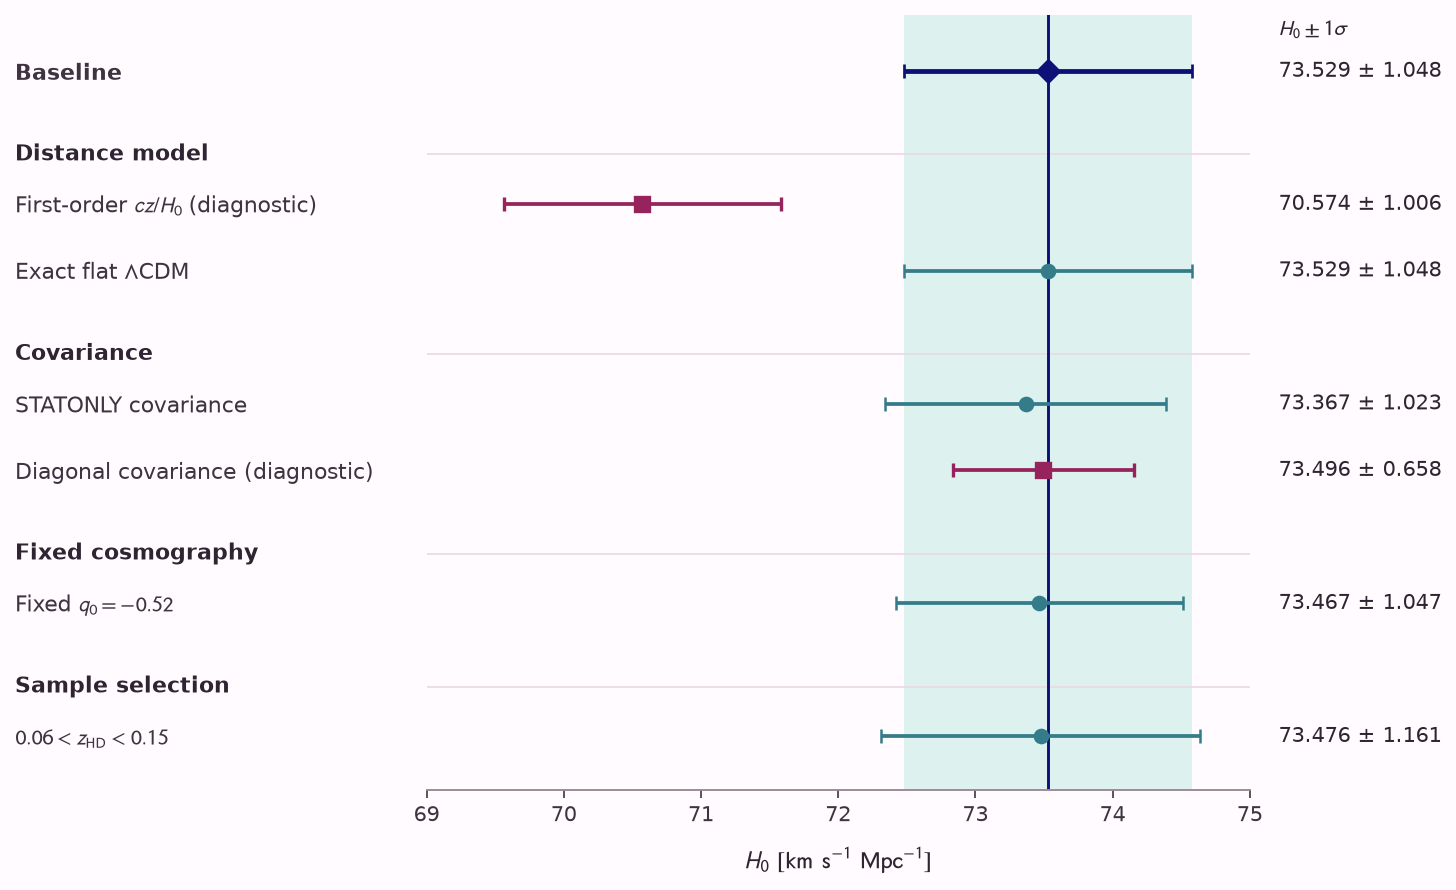

In [46]:
from pathlib import Path

current_dir = Path.cwd().resolve()

project_root = (
    current_dir.parent
    if current_dir.name == "notebooks"
    else current_dir
)

figure_dir = project_root / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

fig, ax = plot_robustness("orchid")

figure_path = figure_dir / "h0_robustness_forest_plot.pdf"

fig.savefig(
    figure_path,
    bbox_inches="tight",
    pad_inches=0.08,
    facecolor=fig.get_facecolor(),
    transparent=False,
)

print(f"Figure saved to: {figure_path.relative_to(project_root)}")
plt.show()

The comparison separates two distinct effects.

The first-order distance law produces the only large displacement of the central value,

$$
\Delta H_0=-2.955\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

and also increases $\chi^2$ by $32.68$ relative to the baseline cosmography. The simplified distance-redshift model therefore explains the approximately $70$ versus $73.5$ difference.

By contrast, replacing the full covariance by its diagonal changes the central value by only

$$
\Delta H_0=-0.033\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

but reduces the reported uncertainty by $37.3\%$. Ignoring correlations therefore creates artificial precision without producing the large shift in $H_0$.

The exact flat-$\Lambda$CDM calculation, moderate variation of $q_0$, `STATONLY` covariance and conservative redshift cut all remain close to the baseline central value. The compressed inference is therefore stable under reasonable analysis variations, while remaining sensitive to an inadequate first-order distance model and to the treatment of correlated uncertainties.

## 10. Conclusions and limitations

### Main result

This notebook investigated whether a compressed, covariance-aware analysis of the Pantheon+SH0ES data can recover a stable local inference of the Hubble constant, and which analysis choices have the largest effect on that inference.

The selected sample contains 77 calibrator rows and 277 Hubble-flow rows, corresponding to 354 measurements of 281 distinct supernovae. Repeated measurements are retained together with the published full `STAT+SYS` covariance matrix.

The analytic generalized least-squares solution gives

$$
H_0
=
73.529\pm1.048\,
\mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

and

$$
M_{\rm SN}
=
-19.2469\pm0.0299\, \mathrm{mag}.
$$

The MCMC posterior gives

$$
H_0
=
73.55^{+1.06}_{-1.03}\,
\mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

with a consistent estimate of $M_{\rm SN}$. The close agreement between MCMC, numerical optimization and the analytic GLS
solution provides a strong internal consistency check of the parameter-estimation
implementation. The autocorrelation times are stable, and the effective sample sizes exceed $10^4$ for all sampled parameters.

### Additional scatter and goodness of fit

Allowing an additional independent magnitude scatter gives a maximum-posterior value at

$$
\sigma_{\rm extra}=0,
$$

with the 95% posterior upper limit

$$
\sigma_{\rm extra}<0.0290\ \mathrm{mag}.
$$

The positive posterior median does not constitute a detection because $\sigma_{\rm extra}$ is restricted to non-negative values. No additional scatter is required by these data beyond the published covariance model.

For the baseline two-parameter fit,

$$
\chi^2=299.906,\qquad
\nu=352,\qquad
\frac{\chi^2}{\nu}=0.852.
$$

The corresponding upper-tail probability is $p=0.980$. Together with the mean and standard deviation of the whitened residuals, $0.019$ and $0.922$, this indicates that the residuals are slightly smaller than expected under the published covariance. The high $p$-value should not be interpreted as proof that the model is exceptionally accurate; it may instead indicate that the covariance is conservative.

### Robustness of the inference

The inferred central value is stable under the scientifically reasonable variations tested here. Using the `STATONLY` covariance, an exact flat-$\Lambda$CDM distance, a moderate change from $q_0=-0.55$ to $q_0=-0.52$, or a more conservative Hubble-flow redshift selection changes $H_0$ by at most

$$
0.162\ \mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

well below the baseline uncertainty.

The two deliberately simplified diagnostic approximations reveal different effects. Replacing the cosmographic distance relation by the first-order law shifts the result by

$$
\Delta H_0=-2.955\
\mathrm{km\,s^{-1}\,Mpc^{-1}}
$$

and increases $\chi^2$ by $32.68$. The distance-redshift model, rather than the covariance treatment alone, therefore explains the approximate shift from $H_0\simeq70.6$ to $H_0\simeq73.5$.

By contrast, discarding all off-diagonal covariance terms changes the central value by only

$$
\Delta H_0=-0.033\
\mathrm{km\,s^{-1}\,Mpc^{-1}},
$$

but reduces its reported uncertainty by $37.3\%$. Ignoring correlations therefore produces artificial precision without explaining the large displacement in the central value.

### Scope and limitations

This analysis has several important limitations:

* The Cepheid distance moduli, corrected supernova magnitudes and covariance matrices are already calibrated products of the Pantheon+SH0ES analysis.
* The model is a compressed two-parameter representation of the distance ladder, not a reconstruction of the complete Cepheid–supernova calibration procedure.
* The cosmographic parameters $q_0$ and $j_0$ are fixed, and the main sample follows the published selection.
* The analysis does not refit the Cepheid period–luminosity relations, photometric zero points, host-galaxy parameters or the complete set of systematic nuisance parameters.
* Most robustness variants reuse the same observations and are strongly correlated. They must not be interpreted as independent measurements of $H_0$.
* The additional-scatter posterior depends partly on the adopted prior near its physical boundary.
* No independent early-Universe dataset is analysed here, so this notebook does not by itself evaluate the statistical significance or physical origin of the Hubble tension.

The result should therefore be described as a pedagogical, covariance-aware reproduction of a compressed Pantheon+SH0ES inference, rather than as a new independent measurement of $H_0$.

Within that scope, the analysis demonstrates three robust conclusions: the central inference is stable under reasonable analysis variations, an inadequate first-order distance model produces a substantial bias, and neglecting published correlations strongly underestimates the uncertainty.
